In [5]:
# ================================================================
# QISM 0: KUTUBXONALARNI O'RNATISH
# ================================================================

print("\n" + "=" * 100)
print("QISM 0: KUTUBXONALARNI O'RNATISH VA IMPORT QILISH")
print("=" * 100)
print()

import subprocess
import sys

print("🔧 Zarur kutubxonalarni o'rnatilmoqda...\n")

# O'rnatish uchun kutubxonalar
packages = {
    'yt-dlp': 'YouTube videolarini yuklash',
    'pydub': 'Audio fayl bilan ishlash',
    'SpeechRecognition': 'Audio → Text konversiya',
    'faster-whisper': 'Whisper bilan MP3 → transcript',
    'textblob': 'Qo\'shimcha sentiment polarity/subjectivity',
    'google-cloud-speech': 'Google Speech API',
    'nltk': 'Natural Language Processing',
    'spacy': 'Advanced NLP',
    'sklearn': 'Topic Modeling (LDA)',
    'gensim': 'Topic Modeling (LSA, LDA)',
    'wordcloud': 'Word Cloud vizualizatsiya',
    'matplotlib': 'Grafiklar',
    'seaborn': 'Statistik vizualizatsiya',
    'pandas': 'Data tahlili',
    'numpy': 'Matematik hisoblash',
}

for package, description in packages.items():
    try:
        __import__(package.replace('-', '_'))
        print(f"  ✓ {package:25s} - {description}")
    except ImportError:
        print(f"  → {package:25s} o'rnatilmoqda...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
            print(f"  ✓ {package:25s} - {description}")
        except:
            print(f"  ⚠️  {package:25s} - O'rnatishda xato")

print("\n✓ Kutubxonalarni o'rnatish yakunlandi!\n")

# Import qilish
import os
import json
import re
from datetime import datetime
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import speech_recognition as sr
from pydub import AudioSegment
from pydub.silence import split_on_silence

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
from sklearn.decomposition import TruncatedSVD

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

print("✓ Barcha kutubxonalar import qilindi!\n")

# NLTK ma'lumotlarini yuklash
print("📚 NLTK ma'lumotlarini yuklash...\n")

nltk_data = ['stopwords', 'punkt', 'wordnet', 'averaged_perceptron_tagger']
for data in nltk_data:
    try:
        nltk.data.find(f'tokenizers/{data}')
    except LookupError:
        nltk.download(data, quiet=True)

print("✓ NLTK ma'lumotlari yuklandi!\n")



QISM 0: KUTUBXONALARNI O'RNATISH VA IMPORT QILISH

🔧 Zarur kutubxonalarni o'rnatilmoqda...

  ✓ yt-dlp                    - YouTube videolarini yuklash
  ✓ pydub                     - Audio fayl bilan ishlash
  → SpeechRecognition         o'rnatilmoqda...
  ✓ SpeechRecognition         - Audio → Text konversiya
  ✓ faster-whisper            - Whisper bilan MP3 → transcript
  → google-cloud-speech       o'rnatilmoqda...
  ✓ google-cloud-speech       - Google Speech API
  ✓ nltk                      - Natural Language Processing
  ✓ spacy                     - Advanced NLP
  ✓ sklearn                   - Topic Modeling (LDA)
  ✓ gensim                    - Topic Modeling (LSA, LDA)
  ✓ wordcloud                 - Word Cloud vizualizatsiya
  ✓ matplotlib                - Grafiklar
  ✓ seaborn                   - Statistik vizualizatsiya
  ✓ pandas                    - Data tahlili
  ✓ numpy                     - Matematik hisoblash

✓ Kutubxonalarni o'rnatish yakunlandi!

✓ Barcha kutubxo

In [ ]:

# ================================================================
# QISM 1: YOUTUBE'DAN VIDEO YUKLASH
# ================================================================

print("\n" + "=" * 100)
print("QISM 1: YOUTUBE'DAN VIDEO YUKLASH")
print("=" * 100)
print()

def download_youtube_video(youtube_url, output_path='downloads'):
    """
    YouTube videosini yuklash va audio chiqarish
    
    Parameters:
    -----------
    youtube_url : str
        YouTube video linki
    output_path : str
        Output papkasi
    
    Returns:
    --------
    audio_file_path : str
        Audio fayl yo'li
    """
    
    import yt_dlp
    
    os.makedirs(output_path, exist_ok=True)
    
    print(f"📥 Video yuklandi: {youtube_url[:50]}...")
    print()
    
    try:
        # yt-dlp parametrlari
        ydl_opts = {
            'format': 'best',
            'postprocessors': [{
                'key': 'FFmpegExtractAudio',
                'preferredcodec': 'mp3',
                'preferredquality': '192',
            }],
            'outtmpl': os.path.join(output_path, '%(title)s.%(ext)s'),
            'quiet': False,
            'no_warnings': False,
        }
        
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(youtube_url, download=True)
            audio_file = os.path.join(output_path, f"{info['title']}.mp3")
        
        print("✓ Video yuklandi!")
        print(f"  Video: {info['title'][:50]}")
        print(f"  Davomiyligi: {info['duration']//60} daqiqa {info['duration']%60} sekund")
        print()
        
        return audio_file, info
    
    except Exception as e:
        print(f"❌ Xato: {e}")
        return None, None

print("✓ YouTube yuklash funktsiyasi tayyorlandi!\n")

# Test (haqiqiy URL'ni qo'ying)
# youtube_url = "https://youtu.be/L1GD8soI1V0?si=y-nven8u1gP4AclT"
youtube_url = 'https://youtu.be/JN3KPFbWCy8?si=o2YkvKfpYlJ1L_ZY'
audio_file, video_info = download_youtube_video(youtube_url)


QISM 1: YOUTUBE'DAN VIDEO YUKLASH

✓ YouTube yuklash funktsiyasi tayyorlandi!

📥 Video yuklandi: https://youtu.be/JN3KPFbWCy8?si=o2YkvKfpYlJ1L_ZY...

[youtube] Extracting URL: https://youtu.be/JN3KPFbWCy8?si=o2YkvKfpYlJ1L_ZY
[youtube] JN3KPFbWCy8: Downloading webpage


[youtube] JN3KPFbWCy8: Downloading android vr player API JSON
[info] JN3KPFbWCy8: Downloading 1 format(s): 18
[download] Destination: downloads/Elon Musk： War, AI, Aliens, Politics, Physics, Video Games, and Humanity ｜ Lex Fridman Podcast #400.mp4
[download] 100% of  306.75MiB in 00:00:35 at 8.72MiB/s     
[ExtractAudio] Destination: downloads/Elon Musk： War, AI, Aliens, Politics, Physics, Video Games, and Humanity ｜ Lex Fridman Podcast #400.mp3
Deleting original file downloads/Elon Musk： War, AI, Aliens, Politics, Physics, Video Games, and Humanity ｜ Lex Fridman Podcast #400.mp4 (pass -k to keep)
✓ Video yuklandi!
  Video: Elon Musk: War, AI, Aliens, Politics, Physics, Vid
  Davomiyligi: 136 daqiqa 46 sekund



In [50]:
# To install: pip install faster-whisper
from pathlib import Path
from faster_whisper import WhisperModel

def find_audio_file():
    if "audio_file" in globals() and audio_file and Path(audio_file).exists():
        return Path(audio_file)

    mp3_files = sorted(Path("downloads").glob("*.mp3"), key=lambda path: path.stat().st_mtime, reverse=True)
    if mp3_files:
        return mp3_files[0]

    raise FileNotFoundError("MP3 topilmadi. Avval download_youtube_video(...) ni ishga tushiring yoki audio_file ga MP3 yo'lini bering.")

audio_path = find_audio_file()
print(f"Transcribing: {audio_path}")

model_size = "base" # Options: tiny, base, small, medium, large-v3
model = WhisperModel(model_size, device="cpu", compute_type="int8")

segments, info = model.transcribe(str(audio_path), beam_size=5)

transcript_parts = []
for segment in segments:
    line = f"[{segment.start:.2f}s -> {segment.end:.2f}s] {segment.text}"
    transcript_parts.append(segment.text.strip())
    print(line)

transcript = " ".join(transcript_parts)
Path("transcript.txt").write_text(transcript, encoding="utf-8")
print("\nSaved transcript to transcript.txt")

Transcribing: downloads/Elon Musk： War, AI, Aliens, Politics, Physics, Video Games, and Humanity ｜ Lex Fridman Podcast #400.mp3
[0.00s -> 7.04s]  The following is a conversation with Elon Musk, his fourth time on this, the Lex Friedman podcast.
[20.56s -> 21.60s]  I thought you were going to finish it.
[25.60s -> 28.08s]  It's one of the greatest themes in all film history.
[30.40s -> 32.00s]  Yeah, that's great.
[33.36s -> 36.64s]  So I was just thinking about the Roman Empire as one does.
[38.56s -> 44.40s]  Does that whole meme where all guys are thinking about the Roman Empire at least once a day?
[44.40s -> 46.96s]  And half the population is confused whether it's true or not.
[47.84s -> 52.24s]  But more seriously, thinking about the wars going on in the world today.
[52.88s -> 59.60s]  And as you know, war and military conquest has been a big part of Roman society and culture
[60.32s -> 65.60s]  and it I think has been a big part of most empires and dynasties throughout human hi

In [51]:
import os
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

DATA_DIR = Path('/home/farhod/Downloads/files/')
DATA_FILE = DATA_DIR / 'transcript.txt'
print('Data directory exists:', DATA_DIR.exists())
print('Transcript exists:', DATA_FILE.exists())
print('Transcript file:', DATA_FILE)

Data directory exists: True
Transcript exists: True
Transcript file: /home/farhod/Downloads/files/transcript.txt


In [52]:
import nltk

for package in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'vader_lexicon']:
    try:
        nltk.download(package, quiet=True)
    except Exception as exc:
        print(f'Could not download {package}: {exc}')

In [53]:
path = DATA_FILE
if not path.exists():
    raise FileNotFoundError(f'Transcript file not found: {path}')

text = path.read_text(encoding='utf-8', errors='ignore').strip()
records = [{
    'file': path.name,
    'speaker': 'Transcript',
    'debate': 1,
    'raw_text': text,
    'characters': len(text),
    'raw_words': len(text.split())
}]

files_df = pd.DataFrame(records).reset_index(drop=True)
files_df

,file,speaker,debate,raw_text,characters,raw_words
0,transcript.txt,Transcript,1,The following is a conversation with Elon Musk...,106937,19537


In [54]:
from nltk.tokenize import sent_tokenize


def safe_sent_tokenize(text):
    try:
        return sent_tokenize(text)
    except LookupError:
        return re.split(r'(?<=[.!?])\s+', text)

sentence_records = []
for _, row in files_df.iterrows():
    sentences = [s.strip() for s in safe_sent_tokenize(row['raw_text']) if s.strip()]
    for i, sentence in enumerate(sentences, start=1):
        sentence_records.append({
            'file': row['file'],
            'speaker': row['speaker'],
            'debate': row['debate'],
            'sentence_id': i,
            'text': sentence,
            'char_len': len(sentence),
            'word_len': len(sentence.split())
        })

df = pd.DataFrame(sentence_records)
print(df.shape)
df.head(10)

(1634, 7)


,file,speaker,debate,sentence_id,text,char_len,word_len
0,transcript.txt,Transcript,1,1,The following is a conversation with Elon Musk...,98,17
1,transcript.txt,Transcript,1,2,I thought you were going to finish it.,38,8
2,transcript.txt,Transcript,1,3,It's one of the greatest themes in all film hi...,52,10
3,transcript.txt,Transcript,1,4,"Yeah, that's great.",19,3
4,transcript.txt,Transcript,1,5,So I was just thinking about the Roman Empire ...,58,12
5,transcript.txt,Transcript,1,6,Does that whole meme where all guys are thinki...,92,18
6,transcript.txt,Transcript,1,7,And half the population is confused whether it...,61,11
7,transcript.txt,Transcript,1,8,"But more seriously, thinking about the wars go...",72,13
8,transcript.txt,Transcript,1,9,"And as you know, war and military conquest has...",182,35
9,transcript.txt,Transcript,1,10,"So yeah, they usually came as a result of conq...",51,10


,,gaplar_soni,ortacha_sozlar,jami_sozlar
speaker,debate,,,
Transcript,1,1634,11.96,19537


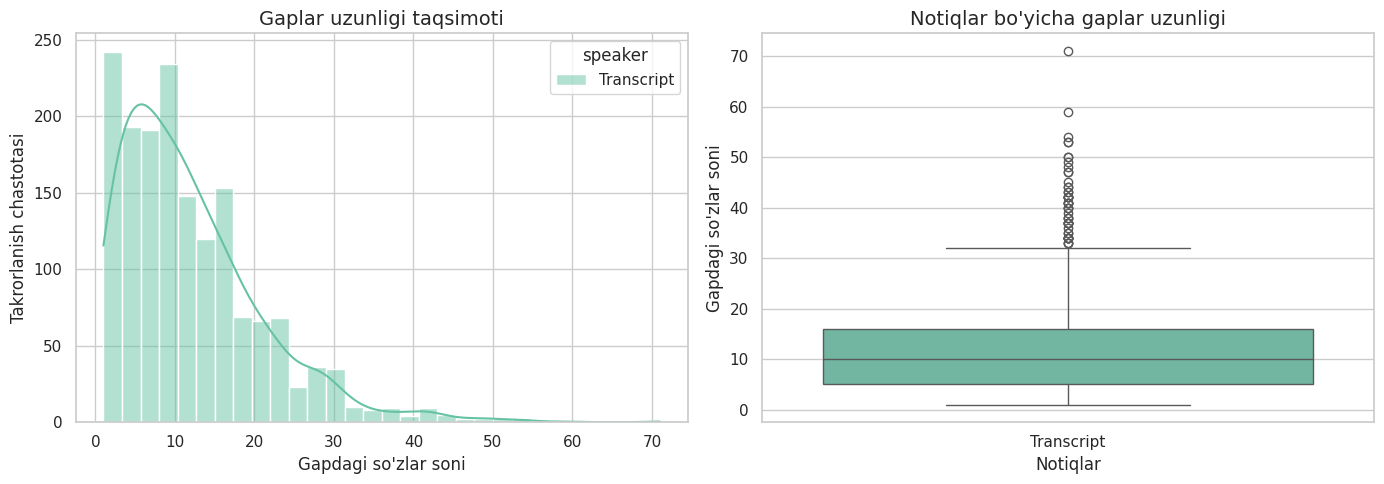

In [55]:
# Guruhlangan statistikani ko'rsatish:
# Bu jadval qaysi notiq ko'proq gapirgani va kim qisqaroq yoki uzunroq gaplarni afzal ko'rishini ko'rsatadi.
summary_df = df.groupby(['speaker', 'debate']).agg(
    gaplar_soni=('text', 'count'),
    ortacha_sozlar=('word_len', 'mean'),
    jami_sozlar=('word_len', 'sum')
).round(2)
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1-Grafik: Gaplar uzunligi taqsimoti (Gistogramma)
sns.histplot(data=df, x='word_len', hue='speaker', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Gaplar uzunligi taqsimoti')
axes[0].set_xlabel('Gapdagi so\'zlar soni')
axes[0].set_ylabel('Takrorlanish chastotasi')

# 2-Grafik: Notiqlar bo'yicha gaplar uzunligi (Boxplot)
sns.boxplot(data=df, x='speaker', y='word_len', ax=axes[1])
axes[1].set_title('Notiqlar bo\'yicha gaplar uzunligi')
axes[1].set_xlabel('Notiqlar')
axes[1].set_ylabel('Gapdagi so\'zlar soni')

plt.tight_layout()


In [56]:
# Inglizcha qisqartmalar lug'ati
CONTRACTIONS = {
    "can't": 'cannot', "won't": 'will not', "n't": ' not', "'re": ' are',
    "'s": ' is', "'d": ' would', "'ll": ' will', "'t": ' not',
    "'ve": ' have', "'m": ' am'
}

def expand_contractions(text):
    """Qisqartmalarni to'liq shaklga keltirish"""
    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)
    return text

def clean_text(text):
    """Matnni tozalash: kichik harfga o'tkazish, belgilarni o'chirish"""
    text = text.lower() # Hammasini kichik harfga o'tkazish
    text = expand_contractions(text) # Qisqartmalarni ochish
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # Linklarni o'chirish
    text = re.sub(r'<.*?>', ' ', text) # HTML teglarni o'chirish
    text = re.sub(r'[^a-z\s]', ' ', text) # Faqat harflarni qoldirish
    text = re.sub(r'\s+', ' ', text).strip() # Ortiqcha bo'shliqlarni tozalash
    return text

# Tozalangan matn uchun yangi ustun yaratish
df['clean_text'] = df['text'].apply(clean_text)
display(df[['text', 'clean_text']].head(10))


,text,clean_text
0,The following is a conversation with Elon Musk...,the following is a conversation with elon musk...
1,I thought you were going to finish it.,i thought you were going to finish it
2,It's one of the greatest themes in all film hi...,it is one of the greatest themes in all film h...
3,"Yeah, that's great.",yeah that is great
4,So I was just thinking about the Roman Empire ...,so i was just thinking about the roman empire ...
5,Does that whole meme where all guys are thinki...,does that whole meme where all guys are thinki...
6,And half the population is confused whether it...,and half the population is confused whether it...
7,"But more seriously, thinking about the wars go...",but more seriously thinking about the wars goi...
8,"And as you know, war and military conquest has...",and as you know war and military conquest has ...
9,"So yeah, they usually came as a result of conq...",so yeah they usually came as a result of conquest


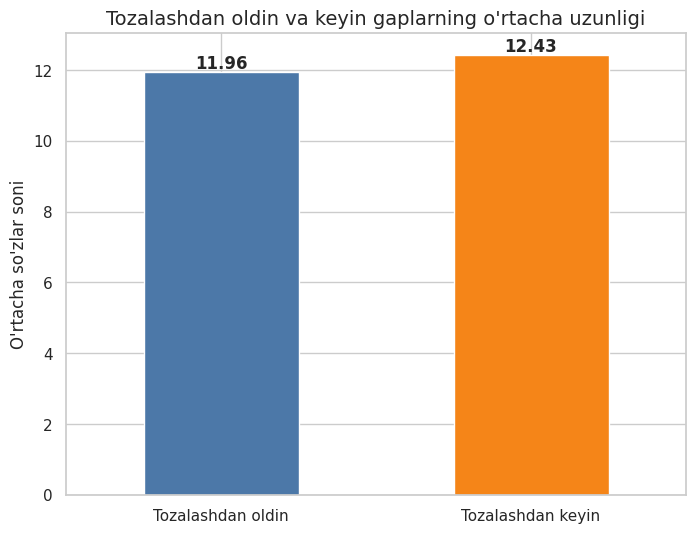

In [57]:
# Tozalangan matndagi so'zlar sonini hisoblash
df['clean_word_len'] = df['clean_text'].str.split().str.len()

# Tozalashdan oldingi va keyingi o'rtacha uzunlikni solishtirish
length_compare = df[['word_len', 'clean_word_len']].mean().rename({
    'word_len': 'Tozalashdan oldin',
    'clean_word_len': 'Tozalashdan keyin'
})

# Grafikni chizish
plt.figure(figsize=(8, 6))
ax = length_compare.plot(kind='bar', color=['#4C78A8', '#F58518'])
ax.set_title('Tozalashdan oldin va keyin gaplarning o\'rtacha uzunligi')
ax.set_ylabel('O\'rtacha so\'zlar soni')
ax.set_xticklabels(length_compare.index, rotation=0)

# Ustunlar ustiga qiymatlarni yozib qo'yish (aniqroq ko'rinishi uchun)
for i, v in enumerate(length_compare):
    ax.text(i, v + 0.1, str(round(v, 2)), ha='center', fontweight='bold')

plt.show()


In [58]:
from nltk.tokenize import word_tokenize


def safe_word_tokenize(text):
    try:
        return word_tokenize(text)
    except LookupError:
        return re.findall(r'[a-z]+', text)

df['tokens'] = df['clean_text'].apply(safe_word_tokenize)
df[['clean_text', 'tokens']].head(10)

,clean_text,tokens
0,the following is a conversation with elon musk...,"[the, following, is, a, conversation, with, el..."
1,i thought you were going to finish it,"[i, thought, you, were, going, to, finish, it]"
2,it is one of the greatest themes in all film h...,"[it, is, one, of, the, greatest, themes, in, a..."
3,yeah that is great,"[yeah, that, is, great]"
4,so i was just thinking about the roman empire ...,"[so, i, was, just, thinking, about, the, roman..."
5,does that whole meme where all guys are thinki...,"[does, that, whole, meme, where, all, guys, ar..."
6,and half the population is confused whether it...,"[and, half, the, population, is, confused, whe..."
7,but more seriously thinking about the wars goi...,"[but, more, seriously, thinking, about, the, w..."
8,and as you know war and military conquest has ...,"[and, as, you, know, war, and, military, conqu..."
9,so yeah they usually came as a result of conquest,"[so, yeah, they, usually, came, as, a, result,..."


In [59]:
# Barcha tokenlarni bitta ro'yxatga yig'ish
all_tokens = [token for tokens in df['tokens'] for token in tokens]

print(f"Jami so'zlar (tokenlar) soni: {len(all_tokens)}")
print(f"Unikal (takrorlanmas) so'zlar soni: {len(set(all_tokens))}")
print(f"Leksik boylik ko'rsatkichi (TTR): {len(set(all_tokens)) / len(all_tokens):.4f}")
print("-" * 30)
print("Dastlabki 30 ta so'z namunasi:")
print(all_tokens[:30])


Jami so'zlar (tokenlar) soni: 20324
Unikal (takrorlanmas) so'zlar soni: 2694
Leksik boylik ko'rsatkichi (TTR): 0.1326
------------------------------
Dastlabki 30 ta so'z namunasi:
['the', 'following', 'is', 'a', 'conversation', 'with', 'elon', 'musk', 'his', 'fourth', 'time', 'on', 'this', 'the', 'lex', 'friedman', 'podcast', 'i', 'thought', 'you', 'were', 'going', 'to', 'finish', 'it', 'it', 'is', 'one', 'of', 'the']


In [60]:
from nltk.corpus import stopwords

try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    stop_words = {'the', 'and', 'is', 'in', 'to', 'of', 'a', 'for', 'on', 'that', 'this', 'we', 'it', 'are'}

# Debate transcripts contain many candidate/moderator references that can dominate topic words.
custom_stopwords = {
    'donald', 'trump', 'hillary', 'clinton', 'secretary', 'lester', 'well',
    'would', 'could', 'also', 'said', 'say', 'one', 'think', 'know', 'going'
}
stop_words = stop_words.union(custom_stopwords)

def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words and len(token) > 2]

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)
df[['tokens', 'tokens_no_stop']].head(10)

,tokens,tokens_no_stop
0,"[the, following, is, a, conversation, with, el...","[following, conversation, elon, musk, fourth, ..."
1,"[i, thought, you, were, going, to, finish, it]","[thought, finish]"
2,"[it, is, one, of, the, greatest, themes, in, a...","[greatest, themes, film, history]"
3,"[yeah, that, is, great]","[yeah, great]"
4,"[so, i, was, just, thinking, about, the, roman...","[thinking, roman, empire]"
5,"[does, that, whole, meme, where, all, guys, ar...","[whole, meme, guys, thinking, roman, empire, l..."
6,"[and, half, the, population, is, confused, whe...","[half, population, confused, whether, true]"
7,"[but, more, seriously, thinking, about, the, w...","[seriously, thinking, wars, world, today]"
8,"[and, as, you, know, war, and, military, conqu...","[war, military, conquest, big, part, roman, so..."
9,"[so, yeah, they, usually, came, as, a, result,...","[yeah, usually, came, result, conquest]"


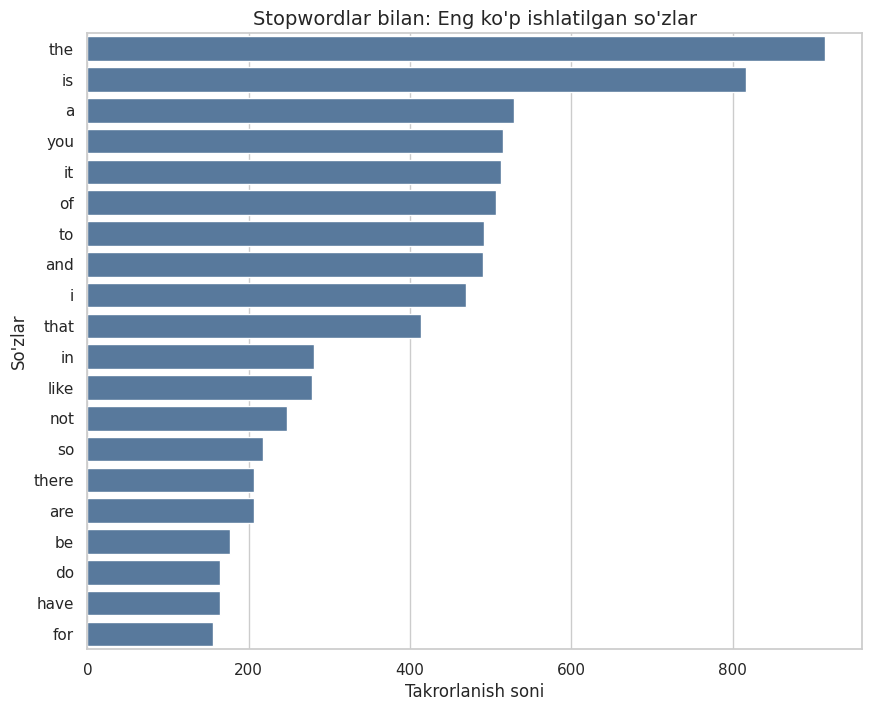

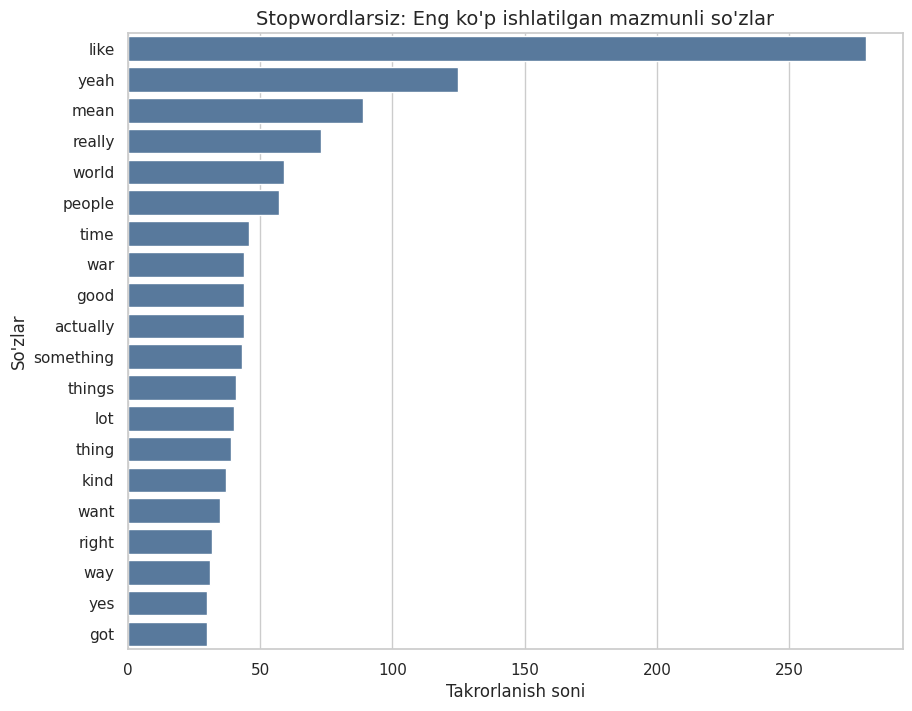

In [61]:
from collections import Counter

def plot_top_words(tokens, title, n=20):
    # Eng ko'p ishlatilgan so'zlarni sanash
    counts = Counter(tokens).most_common(n)
    plot_df = pd.DataFrame(counts, columns=['so\'z', 'soni'])
    
    plt.figure(figsize=(10, 8))
    ax = sns.barplot(data=plot_df, y='so\'z', x='soni', color='#4C78A8')
    
    # Sarlavhalarni o'zbekcha qilish
    ax.set_title(title)
    ax.set_xlabel('Takrorlanish soni')
    ax.set_ylabel('So\'zlar')
    plt.show()

# 1. Stopwordlar bilan birga (umumiy holat)
plot_top_words(all_tokens, 'Stopwordlar bilan: Eng ko\'p ishlatilgan so\'zlar')

# 2. Stopwordlarsiz (mazmunli so'zlar)
all_tokens_no_stop = [token for tokens in df['tokens_no_stop'] for token in tokens]
plot_top_words(all_tokens_no_stop, 'Stopwordlarsiz: Eng ko\'p ishlatilgan mazmunli so\'zlar')


In [62]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
df['stemmed_tokens'] = df['tokens_no_stop'].apply(lambda tokens: [stemmer.stem(token) for token in tokens])
df[['tokens_no_stop', 'stemmed_tokens']].head(10)

,tokens_no_stop,stemmed_tokens
0,"[following, conversation, elon, musk, fourth, ...","[follow, convers, elon, musk, fourth, time, le..."
1,"[thought, finish]","[thought, finish]"
2,"[greatest, themes, film, history]","[greatest, theme, film, histori]"
3,"[yeah, great]","[yeah, great]"
4,"[thinking, roman, empire]","[think, roman, empir]"
5,"[whole, meme, guys, thinking, roman, empire, l...","[whole, meme, guy, think, roman, empir, least,..."
6,"[half, population, confused, whether, true]","[half, popul, confus, whether, true]"
7,"[seriously, thinking, wars, world, today]","[serious, think, war, world, today]"
8,"[war, military, conquest, big, part, roman, so...","[war, militari, conquest, big, part, roman, so..."
9,"[yeah, usually, came, result, conquest]","[yeah, usual, came, result, conquest]"


In [63]:
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    if treebank_tag.startswith('V'):
        return wordnet.VERB
    if treebank_tag.startswith('N'):
        return wordnet.NOUN
    if treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN


def lemmatize_tokens(tokens):
    try:
        tagged = pos_tag(tokens)
        return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]
    except LookupError:
        return [lemmatizer.lemmatize(word) for word in tokens]

df['lemma_tokens'] = df['tokens_no_stop'].apply(lemmatize_tokens)
df['processed_text'] = df['lemma_tokens'].apply(lambda tokens: ' '.join(tokens))
df[['tokens_no_stop', 'stemmed_tokens', 'lemma_tokens', 'processed_text']].head(10)

,tokens_no_stop,stemmed_tokens,lemma_tokens,processed_text
0,"[following, conversation, elon, musk, fourth, ...","[follow, convers, elon, musk, fourth, time, le...","[follow, conversation, elon, musk, fourth, tim...",follow conversation elon musk fourth time lex ...
1,"[thought, finish]","[thought, finish]","[think, finish]",think finish
2,"[greatest, themes, film, history]","[greatest, theme, film, histori]","[great, theme, film, history]",great theme film history
3,"[yeah, great]","[yeah, great]","[yeah, great]",yeah great
4,"[thinking, roman, empire]","[think, roman, empir]","[think, roman, empire]",think roman empire
5,"[whole, meme, guys, thinking, roman, empire, l...","[whole, meme, guy, think, roman, empir, least,...","[whole, meme, guy, think, roman, empire, least...",whole meme guy think roman empire least day
6,"[half, population, confused, whether, true]","[half, popul, confus, whether, true]","[half, population, confuse, whether, true]",half population confuse whether true
7,"[seriously, thinking, wars, world, today]","[serious, think, war, world, today]","[seriously, think, war, world, today]",seriously think war world today
8,"[war, military, conquest, big, part, roman, so...","[war, militari, conquest, big, part, roman, so...","[war, military, conquest, big, part, roman, so...",war military conquest big part roman society c...
9,"[yeah, usually, came, result, conquest]","[yeah, usual, came, result, conquest]","[yeah, usually, come, result, conquest]",yeah usually come result conquest


In [64]:
sample_idx = df['tokens_no_stop'].str.len().sort_values(ascending=False).index[0]
comparison = pd.DataFrame({
    'original_token': df.loc[sample_idx, 'tokens_no_stop'][:25],
    'stemmed': df.loc[sample_idx, 'stemmed_tokens'][:25],
    'lemmatized': df.loc[sample_idx, 'lemma_tokens'][:25]
})
comparison

,original_token,stemmed,lemmatized
0,encourage,encourag,encourage
1,utilities,util,utility
2,build,build,build
3,power,power,power
4,plants,plant,plant
5,probably,probabl,probably
6,probably,probabl,probably
7,definitely,definit,definitely
8,buy,buy,buy
9,batteries,batteri,battery


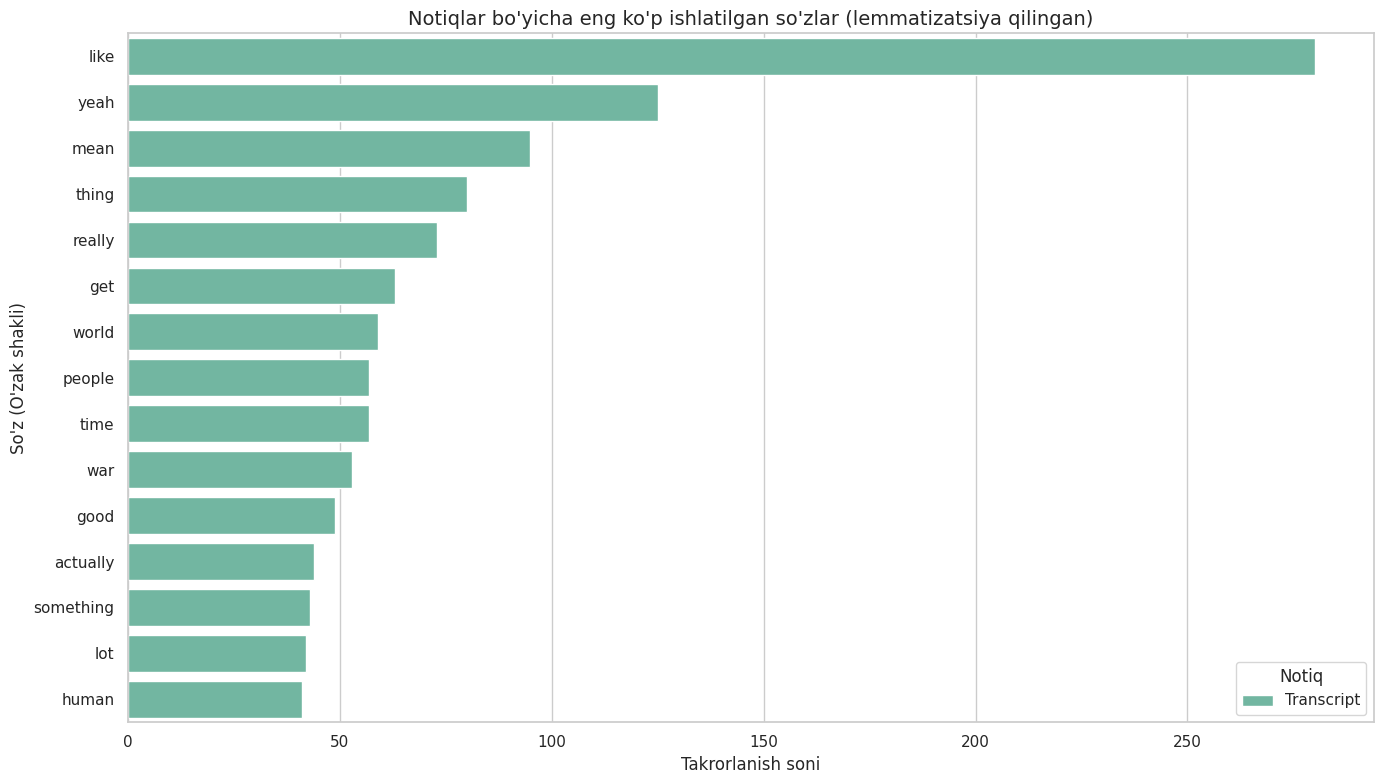

In [65]:
# Har bir notiq bo'yicha so'zlarni guruhlash va sanash
speaker_words = (
    df.explode('lemma_tokens')
      .dropna(subset=['lemma_tokens'])
      .query('lemma_tokens != ""')
      .groupby(['speaker', 'lemma_tokens'])
      .size()
      .reset_index(name='count')
)

# Har bir notiq uchun eng ko'p ishlatilgan top 15 ta so'zni olish
top_by_speaker = speaker_words.sort_values(['speaker', 'count'], ascending=[True, False]).groupby('speaker').head(15)

plt.figure(figsize=(14, 8))
# Grafikni chizish
ax = sns.barplot(data=top_by_speaker, y='lemma_tokens', x='count', hue='speaker')

# Sarlavhalarni o'zbekcha qilish
plt.title('Notiqlar bo\'yicha eng ko\'p ishlatilgan so\'zlar (lemmatizatsiya qilingan)')
plt.xlabel('Takrorlanish soni')
plt.ylabel('So\'z (O\'zak shakli)')
plt.legend(title='Notiq')

plt.tight_layout()
plt.show()


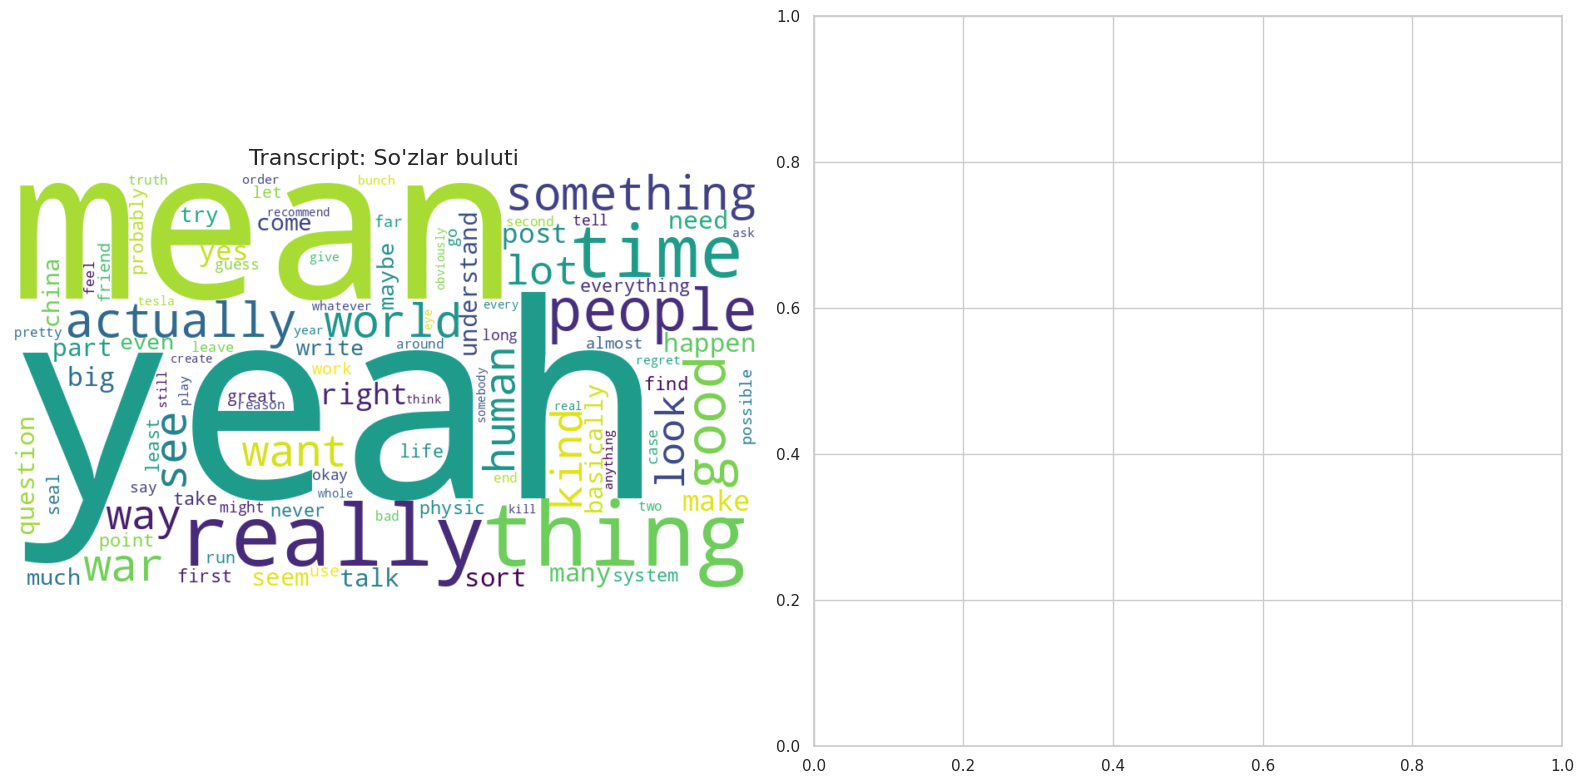

In [66]:
try:
    from wordcloud import WordCloud

    # Notiqlar ro'yxatini olish
    unique_speakers = sorted(df['speaker'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for ax, speaker in zip(axes, unique_speakers):
        # Har bir notiq uchun matnlarni birlashtirish
        text = ' '.join(df.loc[df['speaker'] == speaker, 'processed_text'])
        
        # WordCloud parametrlarini sozlash
        wc = WordCloud(
            width=900, 
            height=500, 
            background_color='white', 
            colormap='viridis',
            max_words=100  # Eng muhim 100 ta so'z
        ).generate(text)
        
        # Grafikni ko'rsatish
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{speaker}: So\'zlar buluti', fontsize=16)
        ax.axis('off') # O'qlarni yashirish

    plt.tight_layout()
    plt.show()
except ImportError:
    print('Xatolik: wordcloud kutubxonasi o\'rnatilmagan.')


In [67]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

sentiment_scores = df['text'].apply(sia.polarity_scores).apply(pd.Series)
df = pd.concat([df, sentiment_scores], axis=1)

def sentiment_label(compound):
    if compound >= 0.05:
        return 'positive'
    if compound <= -0.05:
        return 'negative'
    return 'neutral'

df['sentiment'] = df['compound'].apply(sentiment_label)
df[['speaker', 'debate', 'text', 'neg', 'neu', 'pos', 'compound', 'sentiment']].head(20)

,speaker,debate,text,neg,neu,pos,compound,sentiment
0,Transcript,1,The following is a conversation with Elon Musk...,0.000,1.000,0.000,0.0000,neutral
1,Transcript,1,I thought you were going to finish it.,0.000,1.000,0.000,0.0000,neutral
2,Transcript,1,It's one of the greatest themes in all film hi...,0.000,0.682,0.318,0.6369,positive
3,Transcript,1,"Yeah, that's great.",0.000,0.137,0.863,0.7430,positive
4,Transcript,1,So I was just thinking about the Roman Empire ...,0.000,1.000,0.000,0.0000,neutral
5,Transcript,1,Does that whole meme where all guys are thinki...,0.000,1.000,0.000,0.0000,neutral
6,Transcript,1,And half the population is confused whether it...,0.163,0.638,0.199,0.1280,positive
7,Transcript,1,"But more seriously, thinking about the wars go...",0.402,0.598,0.000,-0.8121,negative
8,Transcript,1,"And as you know, war and military conquest has...",0.112,0.888,0.000,-0.5994,negative
9,Transcript,1,"So yeah, they usually came as a result of conq...",0.000,0.762,0.238,0.3597,positive


In [68]:
sentiment_summary = df.groupby(['speaker', 'debate']).agg(
    sentences=('text', 'count'),
    avg_compound=('compound', 'mean'),
    positive_share=('sentiment', lambda x: (x == 'positive').mean()),
    neutral_share=('sentiment', lambda x: (x == 'neutral').mean()),
    negative_share=('sentiment', lambda x: (x == 'negative').mean())
).round(3)

sentiment_summary

,,sentences,avg_compound,positive_share,neutral_share,negative_share
speaker,debate,,,,,
Transcript,1,1634,0.13,0.48,0.326,0.194


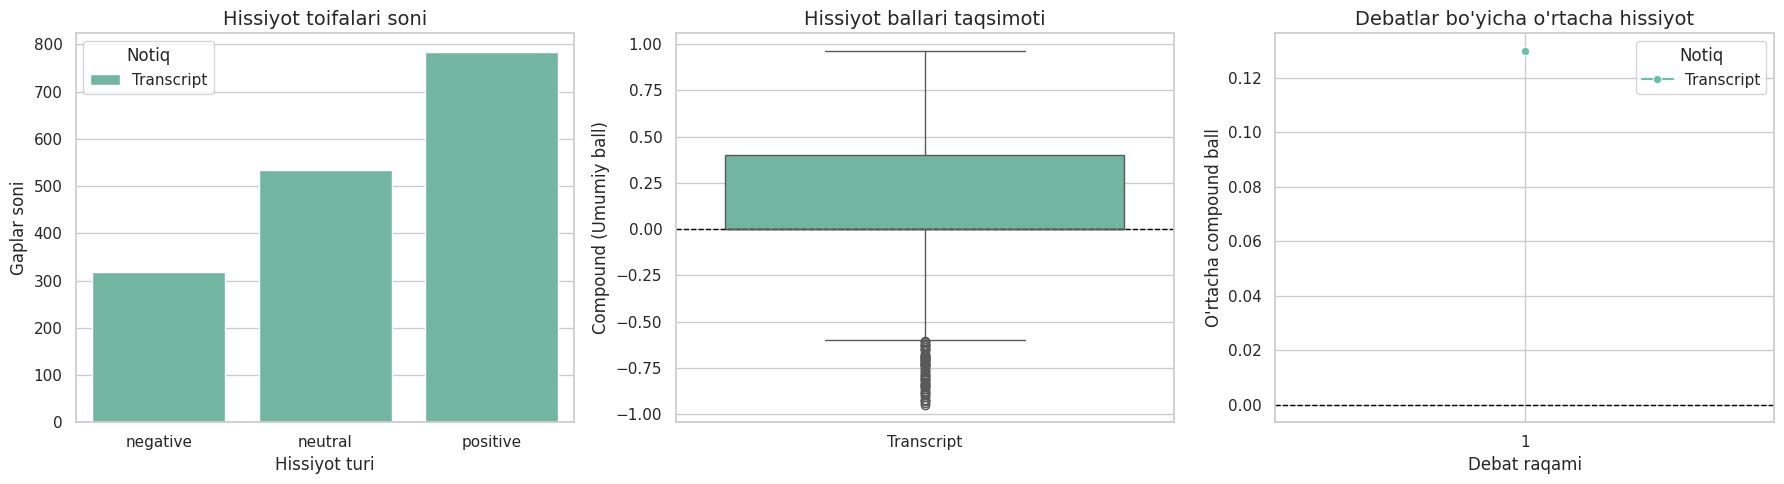

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1-Grafik: Hissiyot toifalari soni 
sns.countplot(data=df, x='sentiment', hue='speaker', order=['negative', 'neutral', 'positive'], ax=axes[0])
axes[0].set_title('Hissiyot toifalari soni')
axes[0].set_xlabel('Hissiyot turi')
axes[0].set_ylabel('Gaplar soni')
axes[0].legend(title='Notiq')

# 2-Grafik: Hissiyot ballari taqsimoti (Boxplot)
sns.boxplot(data=df, x='speaker', y='compound', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1, linestyle='--') 
axes[1].set_title('Hissiyot ballari taqsimoti')
axes[1].set_xlabel('')
axes[1].set_ylabel('Compound (Umumiy ball)')

# 3-Grafik: Debatlar davomida hissiyot o'zgarishi (Lineplot)
avg_sentiment = df.groupby(['speaker', 'debate'], as_index=False)['compound'].mean()
sns.lineplot(data=avg_sentiment, x='debate', y='compound', hue='speaker', marker='o', ax=axes[2])
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Debatlar bo\'yicha o\'rtacha hissiyot')
axes[2].set_xlabel('Debat raqami')
axes[2].set_ylabel('O\'rtacha compound ball')
axes[2].set_xticks(sorted(df['debate'].unique()))
axes[2].legend(title='Notiq')

plt.tight_layout()
plt.show()


In [70]:
# Eng ijobiy gaplarni chiqarish
print('--- Eng ijobiy (pozitiv) gaplar ---')
display(df.sort_values('compound', ascending=False)[['speaker', 'debate', 'compound', 'text']].head(10))

print('\n' + '='*50 + '\n')

# Eng salbiy gaplarni chiqarish
print('--- Eng salbiy (negativ) gaplar ---')
display(df.sort_values('compound')[['speaker', 'debate', 'compound', 'text']].head(10))


--- Eng ijobiy (pozitiv) gaplar ---


,speaker,debate,compound,text
1099,Transcript,1,0.9623,"And, and then recommend based on after it, wha..."
352,Transcript,1,0.9524,There is generally a feeling like this AI syst...
1389,Transcript,1,0.9410,"I mean, if you're in favor of, you know, the e..."
1088,Transcript,1,0.9398,"It's, it's, but you know, like if, let's say i..."
1397,Transcript,1,0.9245,"Are you and AOC secretly friends, or bigger qu..."
860,Transcript,1,0.9231,It's a great power and with great power comes ...
1137,Transcript,1,0.9161,But then like the cheap fun is also valuable.
597,Transcript,1,0.9153,And the actual best person that we were actual...
1477,Transcript,1,0.9128,"Celebrating others, for example, not in a shal..."
1053,Transcript,1,0.9118,"So, you know, it's pretty good if if there's a..."




--- Eng salbiy (negativ) gaplar ---


,speaker,debate,compound,text
178,Transcript,1,-0.9481,But on the other side of a lot of human suffer...
31,Transcript,1,-0.9393,"I mean, the bonobos are an exception, but chim..."
623,Transcript,1,-0.9286,So it's really quite easy to defeat hatred sea...
633,Transcript,1,-0.9245,"It's kind of hilarious that you, Elon Musk, is..."
138,Transcript,1,-0.9209,But now as we sit here with the intensity of c...
83,Transcript,1,-0.9081,"And it's safe to say that if you know, if you ..."
1210,Transcript,1,-0.8990,But no one in the fall left that I'm aware of ...
141,Transcript,1,-0.8883,"Right now, I can be wrong, but I think the cur..."
582,Transcript,1,-0.8861,"And right now, you can ask the Diablo team, bu..."
107,Transcript,1,-0.8793,A lot of people seem to be using this tragedy ...


In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Kerakli resurslarni yuklash
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

sia = SentimentIntensityAnalyzer()

def analyze_text(text):
    # 1. VADER Sentiment (Hissiyot)
    sentiment_score = sia.polarity_scores(text)['compound']
    
    # 2. POS Tagging (Sifatlar sonini aniqlash - notiqning tasvirlash qobiliyati)
    tokens = nltk.word_tokenize(text)
    tags = nltk.pos_tag(tokens)
    # JJ - sifat (adjective), notiqning matni qanchalik rang-barangligini ko'rsatadi
    adj_count = len([word for word, tag in tags if tag == 'JJ'])
    
    # 3. Leksik boylik (Unikal so'zlar nisbati)
    words = text.lower().split()
    lexical_diversity = len(set(words)) / len(words) if len(words) > 0 else 0
    
    return sentiment_score, adj_count, lexical_diversity

# DataFrame-ni yangi ma'lumotlar bilan to'ldiramiz
analysis_results = files_df['raw_text'].apply(analyze_text)
files_df[['sentiment', 'adj_count', 'lexical_richness']] = pd.DataFrame(analysis_results.tolist(), index=files_df.index)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/farhod/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/farhod/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /home/farhod/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


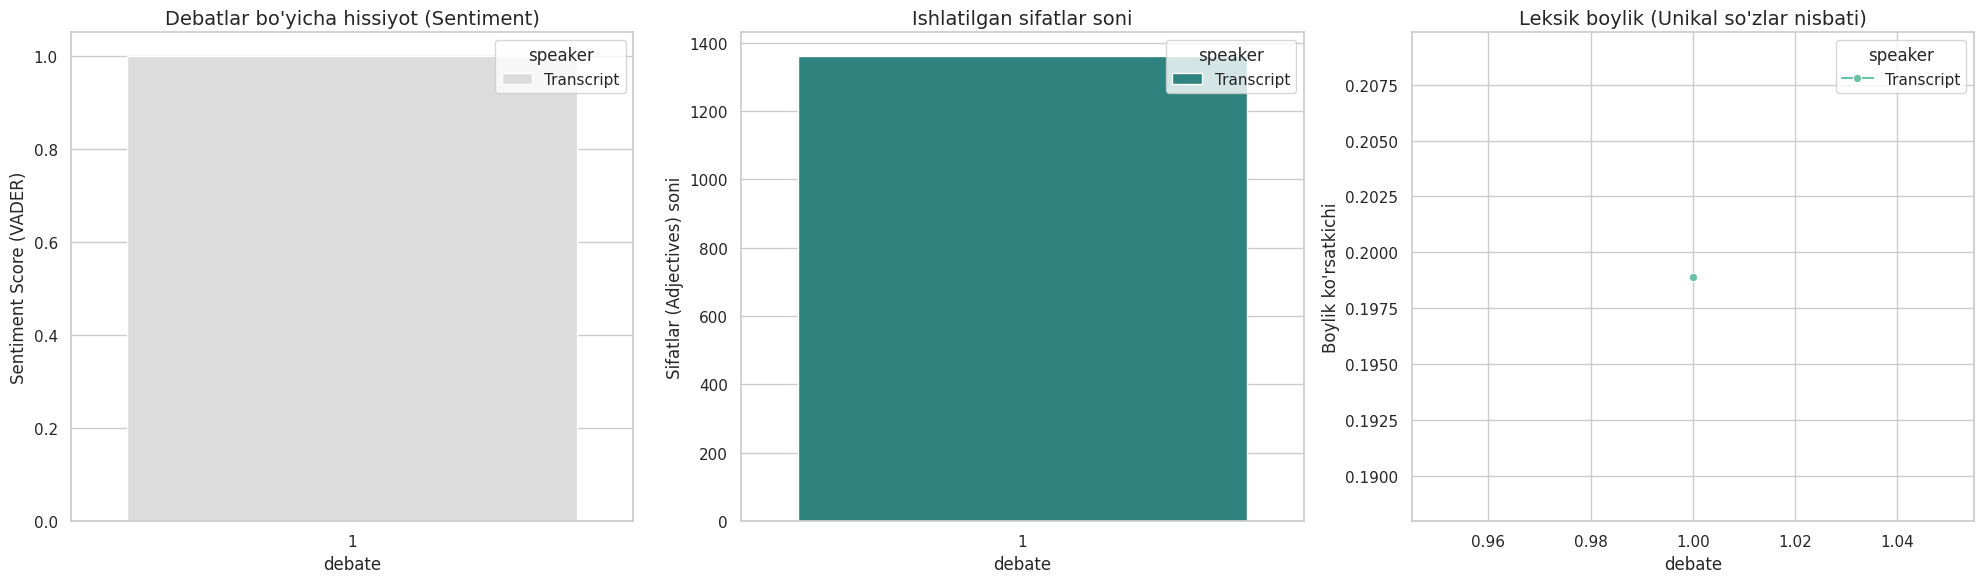

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1-Grafik: Hissiyot tahlili (Sentiment)
sns.barplot(data=files_df, x='debate', y='sentiment', hue='speaker', ax=axes[0], palette='coolwarm')
axes[0].set_title('Debatlar bo\'yicha hissiyot (Sentiment)')
axes[0].set_ylabel('Sentiment Score (VADER)')

# 2-Grafik: Sifatlar soni (Adjectives count) - Notiqning so'z boyligi ifodasi
sns.barplot(data=files_df, x='debate', y='adj_count', hue='speaker', ax=axes[1], palette='viridis')
axes[1].set_title('Ishlatilgan sifatlar soni')
axes[1].set_ylabel('Sifatlar (Adjectives) soni')

# 3-Grafik: Leksik boylik (Lexical Richness)
sns.lineplot(data=files_df, x='debate', y='lexical_richness', hue='speaker', marker='o', ax=axes[2])
axes[2].set_title('Leksik boylik (Unikal so\'zlar nisbati)')
axes[2].set_ylabel('Boylik ko\'rsatkichi')

plt.tight_layout()
plt.show()


In [73]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# VADER yuklash
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# DataFrame yaratilgandan so'ng tahlil qilish
def get_sentiment(text):
    return sia.polarity_scores(text)['compound']

# Yangi ustun qo'shish
files_df['sentiment'] = files_df['raw_text'].apply(get_sentiment)

# Natijani ko'rish
print(files_df[['speaker', 'debate', 'sentiment']].head())


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/farhod/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


      speaker  debate  sentiment
0  Transcript       1        1.0


In [74]:
from sklearn.feature_extraction.text import CountVectorizer

# Kamida 4 ta mazmunli so'zi bor gaplarni saralab olish
topic_df = df[df['processed_text'].str.split().str.len() >= 4].copy().reset_index(drop=True)

# Vektorizatorni sozlash
vectorizer = CountVectorizer(
    max_df=0.85, # O'ta ko'p uchraydigan so'zlarni tashlab yuborish
    min_df=2,    # Kam uchraydigan so'zlarni tashlab yuborish
    max_features=1000, 
    ngram_range=(1, 2) # Birikmalarni ham hisobga olish
)

# Matrisani yaratish
dtm = vectorizer.fit_transform(topic_df['processed_text'])
feature_names = vectorizer.get_feature_names_out()

print(f"Mavzu tahlili uchun tanlangan gaplar soni: {topic_df.shape[0]}")
print(f"Matritsa o'lchami (Gaplar x So'zlar): {dtm.shape}")
print("-" * 30)
print("Dastlabki 20 ta kalit so'z va birikmalar:")
print(feature_names[:20])


Mavzu tahlili uchun tanlangan gaplar soni: 944
Matritsa o'lchami (Gaplar x So'zlar): (944, 1000)
------------------------------
Dastlabki 20 ta kalit so'z va birikmalar:
['ability' 'able' 'account' 'acquisitive' 'act' 'act kindness' 'action'
 'activity' 'actual' 'actually' 'actually help' 'actually want' 'actuator'
 'ad' 'add' 'adhere' 'advertisement' 'advice' 'affect' 'affect future']


In [75]:
from sklearn.decomposition import LatentDirichletAllocation

# LDA modelini sozlash va o'rgatish
N_TOPICS = 5
lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='batch',
    max_iter=20
)

# Matrisani modelga berish
doc_topic = lda_model.fit_transform(dtm)

def show_topics(model, feature_names, n_words=12):
    rows = []
    for topic_idx, topic in enumerate(model.components_):
        # Eng muhim so'zlarning indekslarini topish
        top_indices = topic.argsort()[:-n_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        rows.append({
            'Mavzu raqami': topic_idx + 1,
            'Asosiy kalit so\'zlar': ', '.join(top_words)
        })
    return pd.DataFrame(rows)

# Natijani jadval ko'rinishida ko'rish
topics_summary = show_topics(lda_model, feature_names, n_words=12)
display(topics_summary)


,Mavzu raqami,Asosiy kalit so'zlar
0,1,"like, yeah, note, write, big, question, part, ..."
1,2,"like, thing, china, mean, physic, get, really,..."
2,3,"like, people, war, mean, actually, life, many,..."
3,4,"mean, like, world, sort, open, war, maybe, hum..."
4,5,"like, something, really, thing, lot, need, hap..."


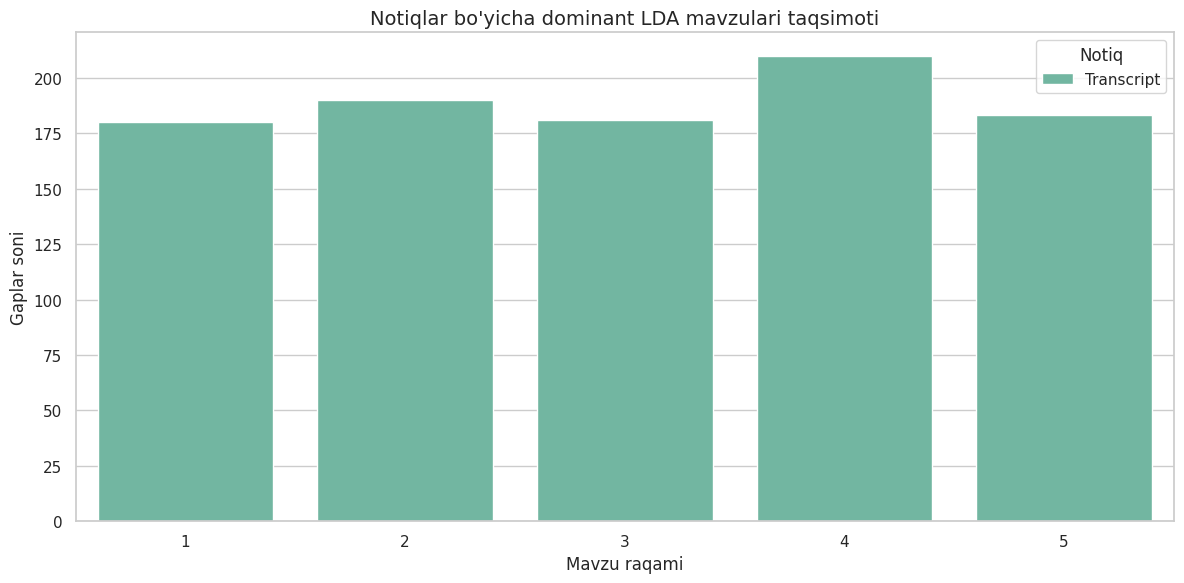

In [76]:
# Har bir gap uchun eng yuqori ehtimollikka ega mavzuni aniqlash
topic_df['dominant_topic'] = doc_topic.argmax(axis=1) + 1
topic_df['topic_probability'] = doc_topic.max(axis=1)

# Notiqlar va mavzular bo'yicha gaplar sonini hisoblash
topic_counts = topic_df.groupby(['speaker', 'dominant_topic']).size().reset_index(name='sentences')

plt.figure(figsize=(12, 6))
# Grafikni chizish
ax = sns.barplot(data=topic_counts, x='dominant_topic', y='sentences', hue='speaker')

# Sarlavhalarni o'zbekcha qilish
plt.title('Notiqlar bo\'yicha dominant LDA mavzulari taqsimoti')
plt.xlabel('Mavzu raqami')
plt.ylabel('Gaplar soni')
plt.legend(title='Notiq')

plt.tight_layout()
plt.show()


# Ushbu kod LDA tahlili natijalarini har bir notiq kesimida vizualizatsiya qiladi.
# Bu orqali qaysi notiq qaysi mavzuga (topic) ko‘proq urg‘u berganini 
# va ularning debatdagi asosiy strategiyasini tushunish mumkin.

In [77]:
# Har bir mavzu bo'yicha statistikani hisoblash
topic_sentiment = topic_df.groupby('dominant_topic').agg(
    gaplar_soni=('text', 'count'),
    ortacha_hissiyot=('compound', 'mean'),
    misol_gap=('text', 'first')
).round(3)

# Natijani ko'rish
display(topic_sentiment)


,gaplar_soni,ortacha_hissiyot,misol_gap
dominant_topic,,,
1,180,0.197,It's one of the greatest themes in all film hi...
2,190,0.165,Many of the leaders were excellent generals.
3,181,0.067,Does that whole meme where all guys are thinki...
4,210,0.088,The following is a conversation with Elon Musk...
5,183,0.170,And half the population is confused whether it...


In [78]:
try:
    import pyLDAvis
    import pyLDAvis.lda_model

    # Notebook muhitida vizualizatsiyani yoqish
    pyLDAvis.enable_notebook()
    
    # LDA modelini vizualizatsiya uchun tayyorlash
    lda_vis = pyLDAvis.lda_model.prepare(lda_model, dtm, vectorizer, sort_topics=False)
    
    # Vizualizatsiyani ko'rsatish
    display(lda_vis)
    
except ImportError:
    print('Xatolik: pyLDAvis o\'rnatilmagan. O\'rnatish uchun: %pip install pyLDAvis')
except Exception as exc:
    print('Vizualizatsiya yaratishda xatolik yuz berdi:', exc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.188550  0.005962       1        1  18.343199
1     -0.015715  0.020129       2        1  21.859060
2     -0.104063 -0.082288       3        1  19.865435
3     -0.006923 -0.107327       4        1  20.642404
4     -0.061850  0.163524       5        1  19.289903, topic_info=          Term       Freq      Total Category  logprob  loglift
901      thing  62.000000  62.000000  Default  30.0000  30.0000
118      china  22.000000  22.000000  Default  29.0000  29.0000
992       yeah  36.000000  36.000000  Default  28.0000  28.0000
855  something  33.000000  33.000000  Default  27.0000  27.0000
603       note  15.000000  15.000000  Default  26.0000  26.0000
..         ...        ...        ...      ...      ...      ...
995       year   6.430535  16.472251   Topic5  -5.2521   0.7050
909       time   8.067957  44.121788   Topic5  -5.0252  -0.0535
192       drug   6.435622  17.236464   Topic5  -5.2513   0.6604
987      write   6.435247  19.786644   Topic5  -5.2513   0.5224
291         go   6.031169  13.829948   Topic5  -5.3162   0.8157

[333 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
4         1  0.726780           act
4         5  0.145356           act
5         1  0.830992  act kindness
9         2  0.192220      actually
9         3  0.448512      actually
...     ...       ...           ...
992       3  0.137959          yeah
992       5  0.055184          yeah
995       2  0.364249          year
995       3  0.182124          year
995       5  0.364249          year

[503 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5])

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

clf_df = df[df['processed_text'].str.len() > 0].copy()
X = clf_df['processed_text']
y = clf_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(max_features=2500, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

sentiment_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
sentiment_clf.fit(X_train_tfidf, y_train)

y_pred = sentiment_clf.predict(X_test_tfidf)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

Accuracy: 0.714
              precision    recall  f1-score   support

    negative       0.57      0.55      0.56        78
     neutral       0.63      0.72      0.67       128
    positive       0.84      0.78      0.80       196

    accuracy                           0.71       402
   macro avg       0.68      0.68      0.68       402
weighted avg       0.72      0.71      0.72       402



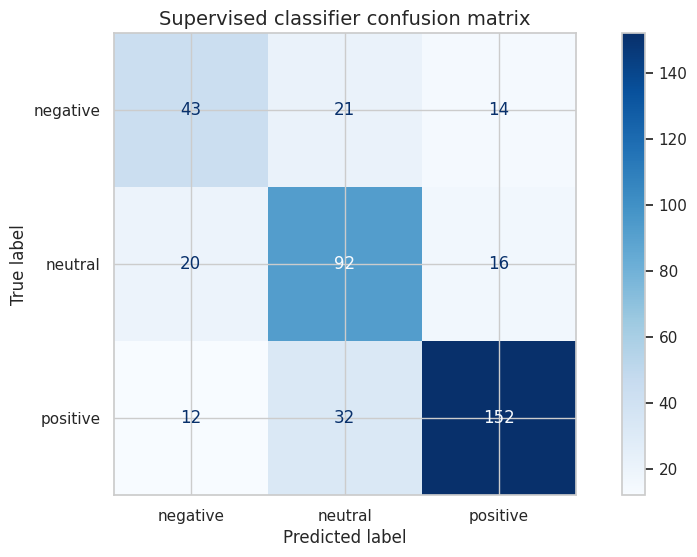

In [80]:
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Supervised classifier confusion matrix')
plt.show()

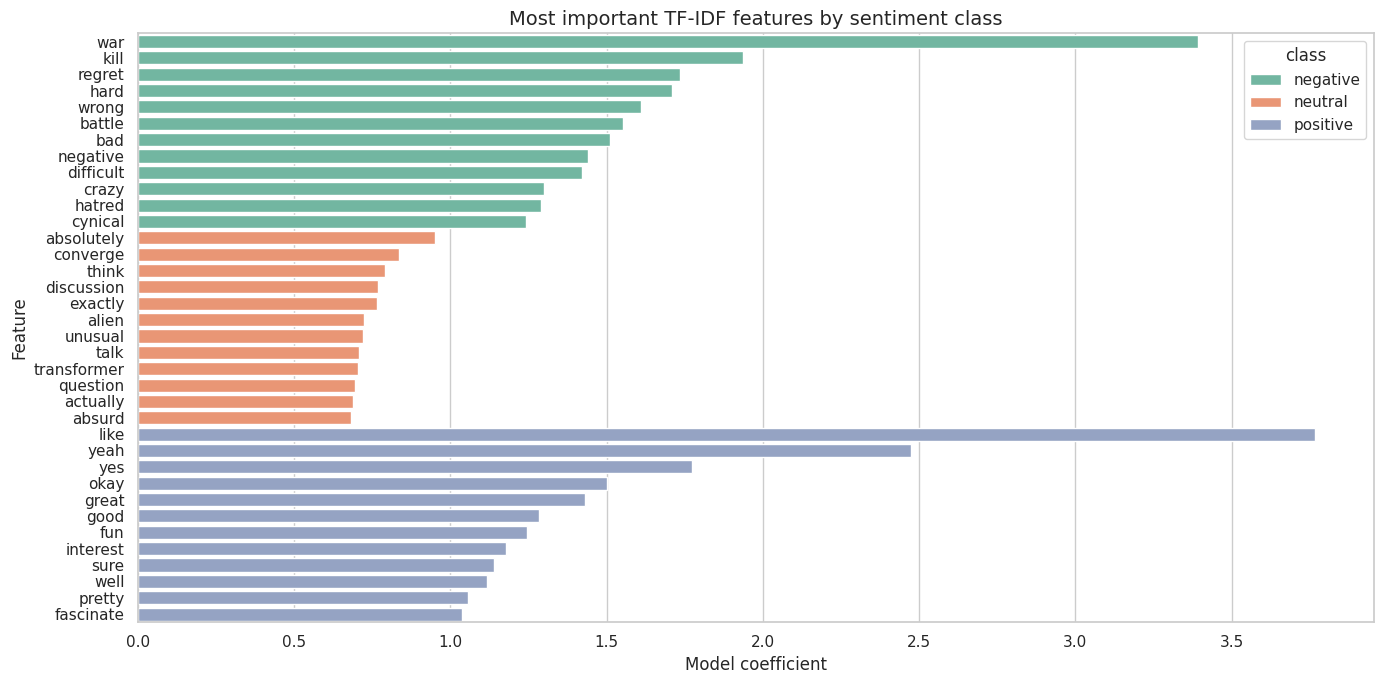

In [81]:
feature_names_tfidf = np.array(tfidf.get_feature_names_out())
coef_df = []

for class_index, class_name in enumerate(sentiment_clf.classes_):
    top_positive = sentiment_clf.coef_[class_index].argsort()[-12:][::-1]
    coef_df.append(pd.DataFrame({
        'class': class_name,
        'feature': feature_names_tfidf[top_positive],
        'weight': sentiment_clf.coef_[class_index][top_positive]
    }))

coef_df = pd.concat(coef_df, ignore_index=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=coef_df, x='weight', y='feature', hue='class')
plt.title('Most important TF-IDF features by sentiment class')
plt.xlabel('Model coefficient')
plt.ylabel('Feature')
plt.tight_layout()

In [82]:
try:
    from textblob import TextBlob

    df['textblob_polarity'] = df['text'].apply(lambda text: TextBlob(text).sentiment.polarity)
    df['textblob_subjectivity'] = df['text'].apply(lambda text: TextBlob(text).sentiment.subjectivity)

    def textblob_label(score):
        if score >= 0.05:
            return 'positive'
        if score <= -0.05:
            return 'negative'
        return 'neutral'

    df['textblob_sentiment'] = df['textblob_polarity'].apply(textblob_label)

    display(df[['speaker', 'debate', 'compound', 'sentiment', 'textblob_polarity', 'textblob_sentiment']].head())
except ImportError:
    print('TextBlob is not installed. Run the setup cell first.')

,speaker,debate,compound,sentiment,textblob_polarity,textblob_sentiment
0,Transcript,1,0.0000,neutral,0.0,neutral
1,Transcript,1,0.0000,neutral,0.0,neutral
2,Transcript,1,0.6369,positive,1.0,positive
3,Transcript,1,0.7430,positive,0.8,positive
4,Transcript,1,0.0000,neutral,0.0,neutral


Correlation: 0.411


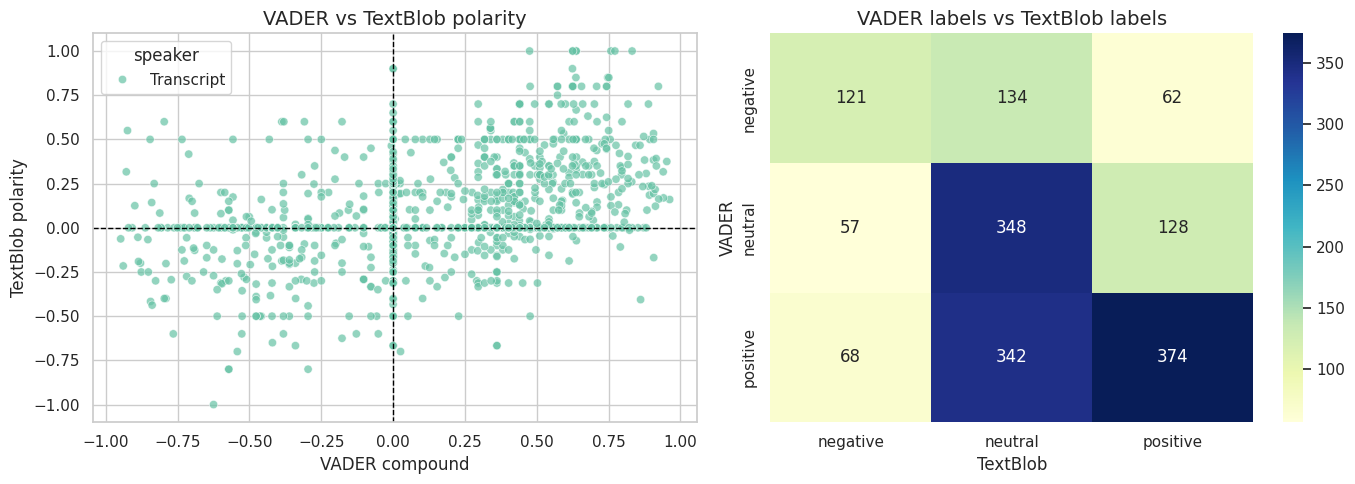

In [83]:
if 'textblob_polarity' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.scatterplot(data=df, x='compound', y='textblob_polarity', hue='speaker', alpha=0.7, ax=axes[0])
    axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
    axes[0].set_title('VADER vs TextBlob polarity')
    axes[0].set_xlabel('VADER compound')
    axes[0].set_ylabel('TextBlob polarity')

    comparison_counts = pd.crosstab(df['sentiment'], df['textblob_sentiment'])
    sns.heatmap(comparison_counts, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1])
    axes[1].set_title('VADER labels vs TextBlob labels')
    axes[1].set_xlabel('TextBlob')
    axes[1].set_ylabel('VADER')

    plt.tight_layout()

    print('Correlation:', round(df[['compound', 'textblob_polarity']].corr().iloc[0, 1], 3))

## Deeper Sentiment Geometry with t-SNE

These cells project sentence-level TF-IDF features into 2D with t-SNE, then compare where positive, neutral, and negative sentences sit in the transcript. Use the tables after the plots to read the actual sentences behind extreme or unusual points.


In [84]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Sentence-level dataset for sentiment geometry
sentiment_tsne_df = df[df['processed_text'].fillna('').str.split().str.len() >= 3].copy()
sentiment_tsne_df['df_index'] = sentiment_tsne_df.index
sentiment_tsne_df = sentiment_tsne_df.reset_index(drop=True)
sentiment_tsne_df['sentence_id'] = np.arange(len(sentiment_tsne_df))
sentiment_tsne_df['word_count'] = sentiment_tsne_df['text'].str.split().str.len()
sentiment_tsne_df['sentiment_strength'] = sentiment_tsne_df['compound'].abs()
sentiment_tsne_df['sentiment_bin'] = pd.cut(
    sentiment_tsne_df['compound'],
    bins=[-1.01, -0.5, -0.05, 0.05, 0.5, 1.01],
    labels=['strong negative', 'mild negative', 'neutral', 'mild positive', 'strong positive']
)
sentiment_tsne_df['snippet'] = sentiment_tsne_df['text'].str.replace(r'\s+', ' ', regex=True).str.slice(0, 220)

print('Sentences used for t-SNE:', len(sentiment_tsne_df))
display(sentiment_tsne_df[['sentence_id', 'sentiment', 'sentiment_bin', 'compound', 'word_count', 'snippet']].head(10))


Sentences used for t-SNE: 1140


,sentence_id,sentiment,sentiment_bin,compound,word_count,snippet
0,0,neutral,neutral,0.0000,17,The following is a conversation with Elon Musk...
1,1,positive,strong positive,0.6369,10,It's one of the greatest themes in all film hi...
2,2,neutral,neutral,0.0000,12,So I was just thinking about the Roman Empire ...
3,3,neutral,neutral,0.0000,18,Does that whole meme where all guys are thinki...
4,4,positive,mild positive,0.1280,11,And half the population is confused whether it...
5,5,negative,strong negative,-0.8121,13,"But more seriously, thinking about the wars go..."
6,6,negative,strong negative,-0.5994,35,"And as you know, war and military conquest has..."
7,7,positive,mild positive,0.3597,10,"So yeah, they usually came as a result of conq..."
8,8,positive,strong positive,0.6378,19,"I mean, there's something like the Orchardanga..."
9,9,positive,strong positive,0.8720,13,"But fundamentally, there's an engine of conque..."


In [85]:
if len(sentiment_tsne_df) < 5:
    raise ValueError('Need at least 5 usable sentences for t-SNE. Try using a longer transcript or shorter sentence chunks.')

min_df = 2 if len(sentiment_tsne_df) >= 30 else 1
tfidf_tsne = TfidfVectorizer(
    max_features=2500,
    min_df=min_df,
    max_df=0.9,
    ngram_range=(1, 2)
)
X_tfidf_tsne = tfidf_tsne.fit_transform(sentiment_tsne_df['processed_text'])

n_svd_components = min(50, X_tfidf_tsne.shape[1] - 1, len(sentiment_tsne_df) - 1)
if n_svd_components >= 2:
    svd_tsne = TruncatedSVD(n_components=n_svd_components, random_state=42)
    X_for_tsne = svd_tsne.fit_transform(X_tfidf_tsne)
    explained = svd_tsne.explained_variance_ratio_.sum()
    print(f'SVD components: {n_svd_components}; explained TF-IDF variance: {explained:.2%}')
else:
    X_for_tsne = X_tfidf_tsne.toarray()
    print('Using dense TF-IDF directly because the feature matrix is small.')

X_for_tsne = StandardScaler().fit_transform(X_for_tsne)
perplexity = min(40, max(5, (len(sentiment_tsne_df) - 1) // 3))

tsne_model = TSNE(
    n_components=2,
    perplexity=perplexity,
    init='pca',
    learning_rate='auto',
    random_state=42
)
tsne_coords = tsne_model.fit_transform(X_for_tsne)
sentiment_tsne_df['tsne_x'] = tsne_coords[:, 0]
sentiment_tsne_df['tsne_y'] = tsne_coords[:, 1]

print('t-SNE perplexity:', perplexity)
sentiment_tsne_df[['sentence_id', 'tsne_x', 'tsne_y', 'sentiment', 'compound', 'snippet']].head()


SVD components: 50; explained TF-IDF variance: 21.67%
t-SNE perplexity: 40


,sentence_id,tsne_x,tsne_y,sentiment,compound,snippet
0,0,34.765808,4.792820,neutral,0.0000,The following is a conversation with Elon Musk...
1,1,-0.425301,-17.268633,positive,0.6369,It's one of the greatest themes in all film hi...
2,2,-3.111093,-1.225619,neutral,0.0000,So I was just thinking about the Roman Empire ...
3,3,-3.510014,-1.353157,neutral,0.0000,Does that whole meme where all guys are thinki...
4,4,4.560202,-1.968884,positive,0.1280,And half the population is confused whether it...


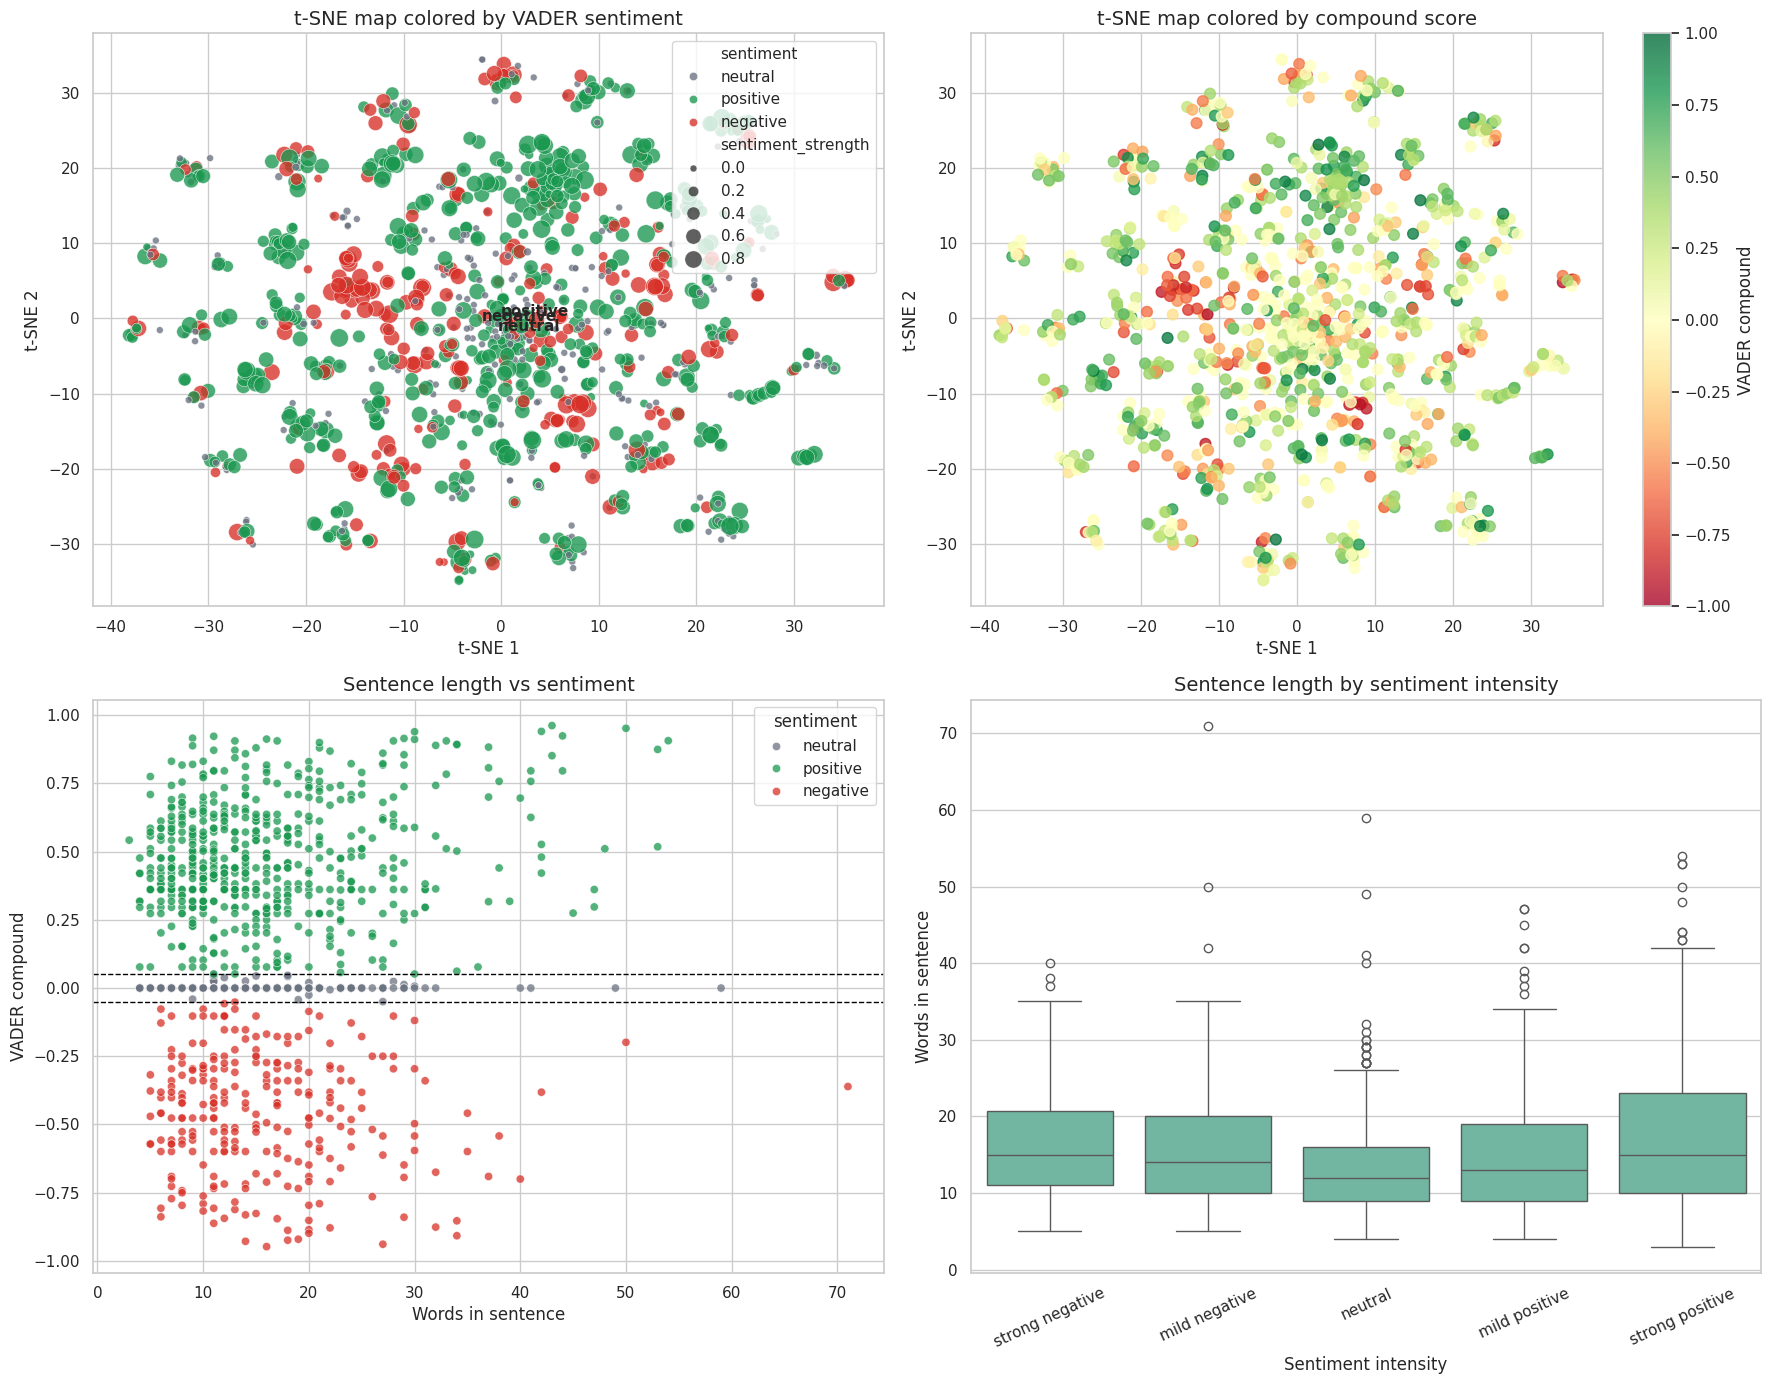

In [86]:
palette = {'negative': '#d73027', 'neutral': '#6b7280', 'positive': '#1a9850'}
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.scatterplot(
    data=sentiment_tsne_df, x='tsne_x', y='tsne_y',
    hue='sentiment', size='sentiment_strength', sizes=(25, 180),
    alpha=0.78, palette=palette, ax=axes[0, 0]
)
axes[0, 0].set_title('t-SNE map colored by VADER sentiment')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')

centroids = sentiment_tsne_df.groupby('sentiment')[['tsne_x', 'tsne_y']].mean().reset_index()
for _, row in centroids.iterrows():
    axes[0, 0].text(row['tsne_x'], row['tsne_y'], row['sentiment'], weight='bold', fontsize=11)

compound_scatter = axes[0, 1].scatter(
    sentiment_tsne_df['tsne_x'], sentiment_tsne_df['tsne_y'],
    c=sentiment_tsne_df['compound'], cmap='RdYlGn', s=60, alpha=0.78, vmin=-1, vmax=1
)
axes[0, 1].set_title('t-SNE map colored by compound score')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
fig.colorbar(compound_scatter, ax=axes[0, 1], label='VADER compound')

sns.scatterplot(
    data=sentiment_tsne_df, x='word_count', y='compound',
    hue='sentiment', alpha=0.75, palette=palette, ax=axes[1, 0]
)
axes[1, 0].axhline(0.05, color='black', linewidth=1, linestyle='--')
axes[1, 0].axhline(-0.05, color='black', linewidth=1, linestyle='--')
axes[1, 0].set_title('Sentence length vs sentiment')
axes[1, 0].set_xlabel('Words in sentence')
axes[1, 0].set_ylabel('VADER compound')

sns.boxplot(data=sentiment_tsne_df, x='sentiment_bin', y='word_count', ax=axes[1, 1])
axes[1, 1].set_title('Sentence length by sentiment intensity')
axes[1, 1].set_xlabel('Sentiment intensity')
axes[1, 1].set_ylabel('Words in sentence')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


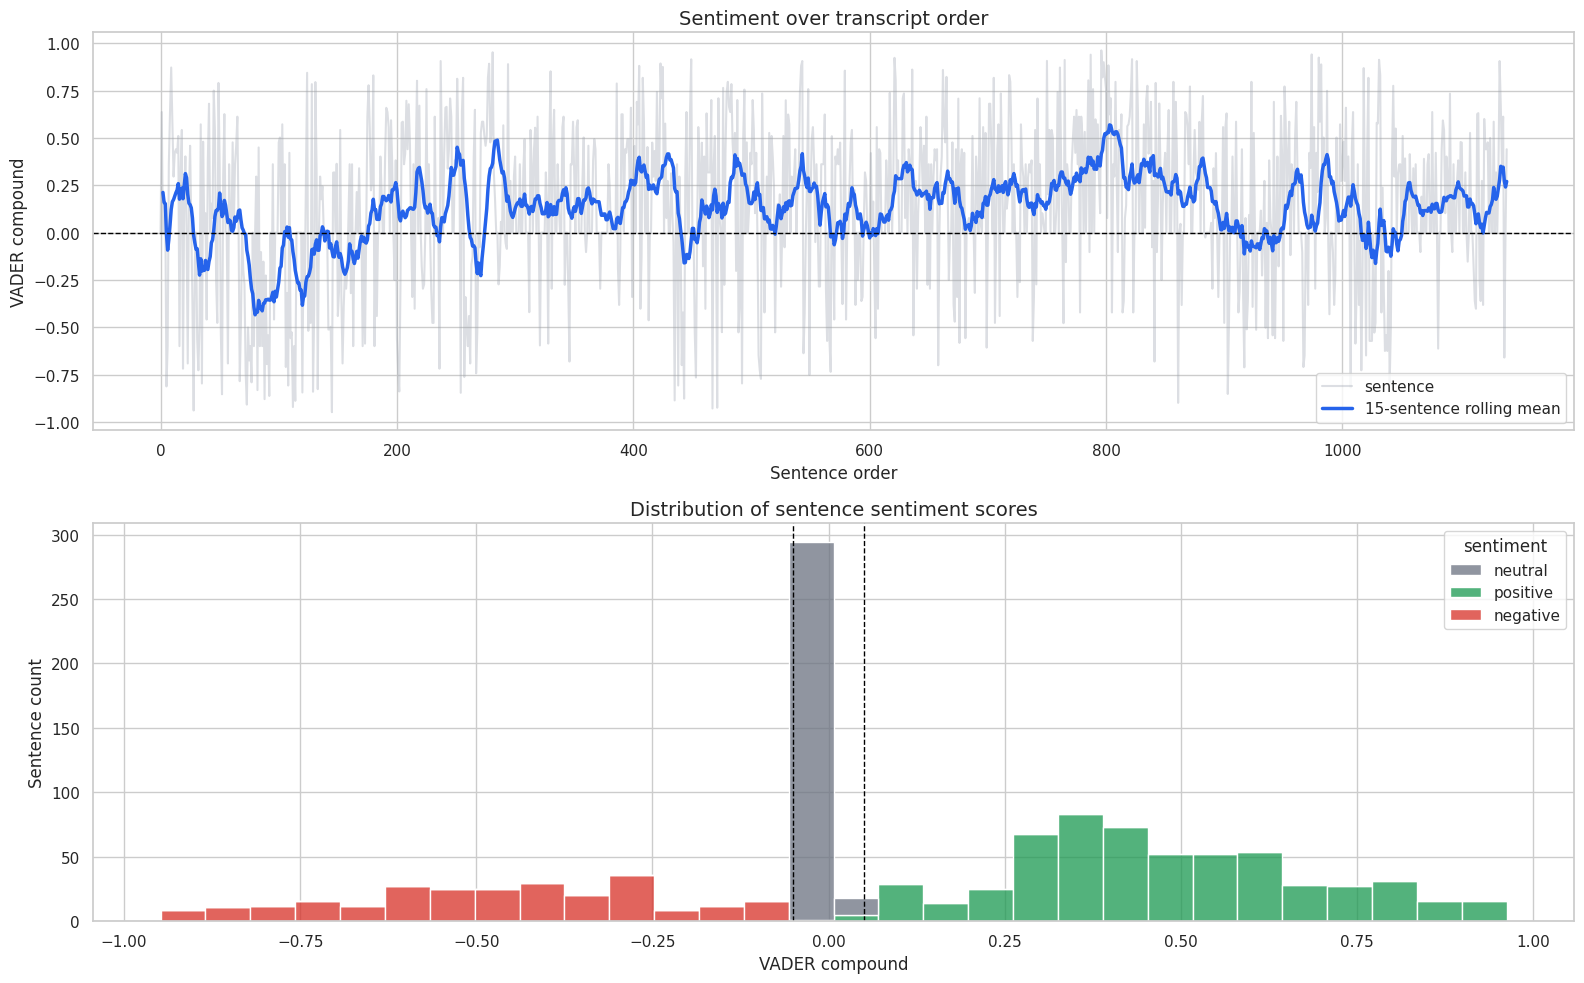

,sentence_count
sentiment_bin,
strong negative,114
mild negative,147
neutral,306
mild positive,332
strong positive,241


In [87]:
# Rolling sentiment shows where the transcript becomes more positive or negative over time.
rolling_window = 15
sentiment_tsne_df['rolling_compound'] = sentiment_tsne_df['compound'].rolling(rolling_window, min_periods=3).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

sns.lineplot(data=sentiment_tsne_df, x='sentence_id', y='compound', color='#9ca3af', alpha=0.35, ax=axes[0], label='sentence')
sns.lineplot(data=sentiment_tsne_df, x='sentence_id', y='rolling_compound', color='#2563eb', linewidth=2.5, ax=axes[0], label=f'{rolling_window}-sentence rolling mean')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Sentiment over transcript order')
axes[0].set_xlabel('Sentence order')
axes[0].set_ylabel('VADER compound')

sns.histplot(data=sentiment_tsne_df, x='compound', hue='sentiment', bins=30, multiple='stack', palette=palette, ax=axes[1])
axes[1].axvline(0.05, color='black', linewidth=1, linestyle='--')
axes[1].axvline(-0.05, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Distribution of sentence sentiment scores')
axes[1].set_xlabel('VADER compound')
axes[1].set_ylabel('Sentence count')

plt.tight_layout()
plt.show()

sentiment_distribution = sentiment_tsne_df['sentiment_bin'].value_counts().reindex([
    'strong negative', 'mild negative', 'neutral', 'mild positive', 'strong positive'
]).fillna(0).astype(int)
display(sentiment_distribution.to_frame('sentence_count'))


In [88]:
# Read the points behind the picture: strongest examples and central examples.
positive_examples = sentiment_tsne_df.nlargest(8, 'compound')[['sentence_id', 'compound', 'word_count', 'snippet']]
negative_examples = sentiment_tsne_df.nsmallest(8, 'compound')[['sentence_id', 'compound', 'word_count', 'snippet']]
neutral_examples = sentiment_tsne_df.iloc[(sentiment_tsne_df['compound'].abs()).argsort()[:8]][['sentence_id', 'compound', 'word_count', 'snippet']]

print('Strongest positive sentences')
display(positive_examples)

print('Strongest negative sentences')
display(negative_examples)

print('Most neutral sentences')
display(neutral_examples)


Strongest positive sentences


,sentence_id,compound,word_count,snippet
796,796,0.9623,43,"And, and then recommend based on after it, wha..."
281,281,0.9524,50,There is generally a feeling like this AI syst...
974,974,0.9410,42,"I mean, if you're in favor of, you know, the e..."
787,787,0.9398,30,"It's, it's, but you know, like if, let's say i..."
980,980,0.9245,44,"Are you and AOC secretly friends, or bigger qu..."
621,621,0.9231,11,It's a great power and with great power comes ...
822,822,0.9161,9,But then like the cheap fun is also valuable.
449,449,0.9153,29,And the actual best person that we were actual...


Strongest negative sentences


,sentence_id,compound,word_count,snippet
145,145,-0.9481,16,But on the other side of a lot of human suffer...
28,28,-0.9393,27,"I mean, the bonobos are an exception, but chim..."
467,467,-0.9286,14,So it's really quite easy to defeat hatred sea...
471,471,-0.9245,18,"It's kind of hilarious that you, Elon Musk, is..."
112,112,-0.9209,19,But now as we sit here with the intensity of c...
73,73,-0.9081,34,"And it's safe to say that if you know, if you ..."
861,861,-0.8990,20,But no one in the fall left that I'm aware of ...
114,114,-0.8883,18,"Right now, I can be wrong, but I think the cur..."


Most neutral sentences


,sentence_id,compound,word_count,snippet
310,310,0.0,11,"That's one of the hardest class in college, by..."
361,361,0.0,40,A lot of people have asked me if I've seen any...
359,359,0.0,19,"Literally, this system goes to be able to ask ..."
344,344,0.0,6,What dimensions does do emotions exist?
343,343,0.0,7,But on what dimension does thought exist?
599,599,0.0,16,Because the peak to trough ratio for power pla...
598,598,0.0,15,So I expect that there will be very heavy usag...
226,226,0.0,9,"In the full menu of POW, very much so."


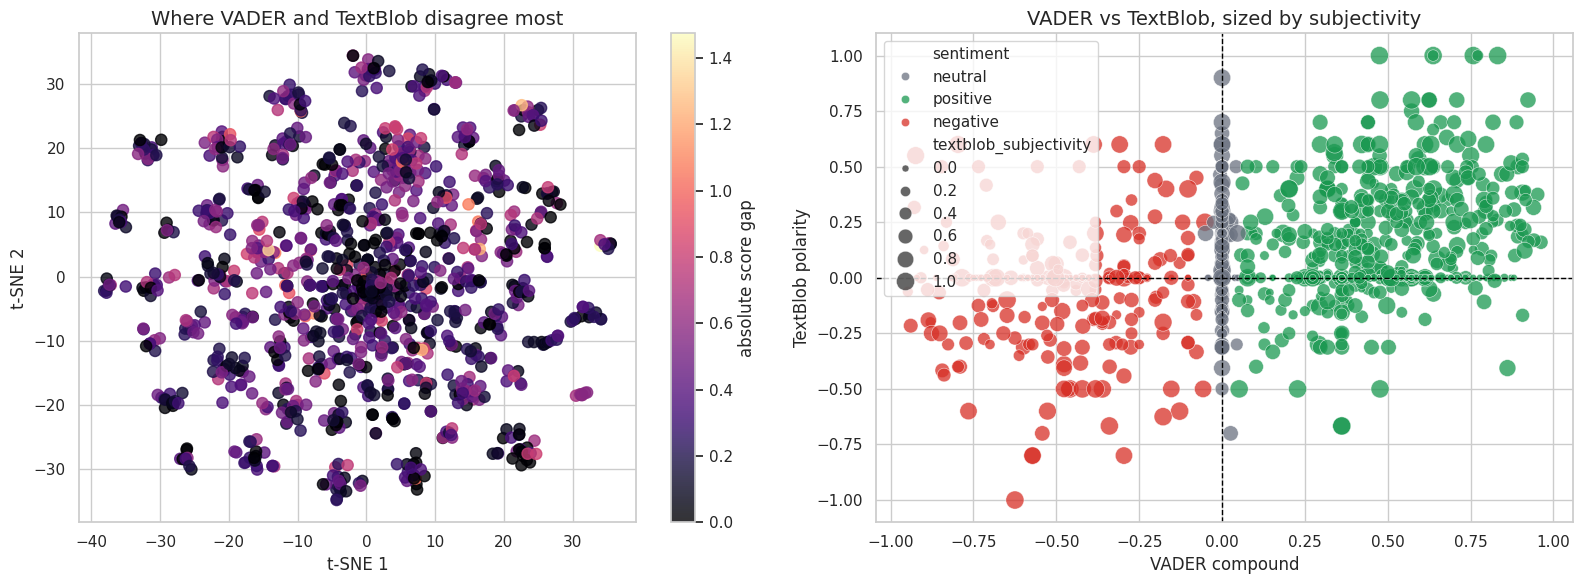

Largest VADER/TextBlob disagreements


,sentence_id,compound,textblob_polarity,textblob_subjectivity,vader_textblob_gap,snippet
471,471,-0.9245,0.550000,0.950000,1.474500,"It's kind of hilarious that you, Elon Musk, is..."
35,35,-0.7967,0.600000,0.950000,1.396700,"They're not like peace loving, basically, at all."
254,254,-0.8458,0.500000,0.500000,1.345800,But I'd venture to say that this is probably t...
636,636,0.8612,-0.406250,0.843750,1.267450,"I mean, some of the things like that, I feel l..."
467,467,-0.9286,0.316667,0.516667,1.245267,So it's really quite easy to defeat hatred sea...
72,72,-0.7348,0.500000,0.500000,1.234800,"And if you create more than you kill, you've n..."
917,917,-0.7114,0.416667,0.500000,1.128067,"But if I did not agree to pay the fine, Tesla ..."
82,82,-0.8316,0.250000,0.333333,1.081600,The first book starts off with a gigantic gala...
750,750,0.9069,-0.168750,0.506250,1.075650,"It's disparate, but there's some little there'..."
200,200,-0.5574,0.500000,0.500000,1.057400,"There have been many, many civil wars."


In [89]:
# Optional: compare TextBlob and VADER if TextBlob columns were created earlier.
if {'textblob_polarity', 'textblob_subjectivity'}.issubset(df.columns):
    sentiment_tsne_df[['textblob_polarity', 'textblob_subjectivity']] = df.loc[sentiment_tsne_df['df_index'], ['textblob_polarity', 'textblob_subjectivity']].to_numpy()
    sentiment_tsne_df['vader_textblob_gap'] = (sentiment_tsne_df['compound'] - sentiment_tsne_df['textblob_polarity']).abs()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    gap_scatter = axes[0].scatter(
        sentiment_tsne_df['tsne_x'], sentiment_tsne_df['tsne_y'],
        c=sentiment_tsne_df['vader_textblob_gap'], cmap='magma', s=65, alpha=0.8
    )
    axes[0].set_title('Where VADER and TextBlob disagree most')
    axes[0].set_xlabel('t-SNE 1')
    axes[0].set_ylabel('t-SNE 2')
    fig.colorbar(gap_scatter, ax=axes[0], label='absolute score gap')

    sns.scatterplot(
        data=sentiment_tsne_df, x='compound', y='textblob_polarity',
        hue='sentiment', size='textblob_subjectivity', sizes=(25, 170),
        alpha=0.75, palette=palette, ax=axes[1]
    )
    axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
    axes[1].set_title('VADER vs TextBlob, sized by subjectivity')
    axes[1].set_xlabel('VADER compound')
    axes[1].set_ylabel('TextBlob polarity')

    plt.tight_layout()
    plt.show()

    print('Largest VADER/TextBlob disagreements')
    display(sentiment_tsne_df.nlargest(10, 'vader_textblob_gap')[[
        'sentence_id', 'compound', 'textblob_polarity', 'textblob_subjectivity', 'vader_textblob_gap', 'snippet'
    ]])
else:
    print('TextBlob columns are not available. Run the TextBlob cell first if you want disagreement analysis.')


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5406.97it/s]


,speaker,debate,sentiment,compound,transformer_label,transformer_score,text
1360,Transcript,1,positive,0.4215,NEGATIVE,0.523346,This is actually helpful because if you actual...
1096,Transcript,1,positive,0.5719,NEGATIVE,0.990042,"Can I write the movie until like, yeah, langua..."
544,Transcript,1,neutral,0.0000,NEGATIVE,0.981028,And it may be open now and then never open again.
506,Transcript,1,neutral,0.0000,NEGATIVE,0.978070,That didn't have spaceships.
874,Transcript,1,neutral,0.0000,NEGATIVE,0.998102,"According to rules, I'm told you need some sor..."
1031,Transcript,1,positive,0.9069,POSITIVE,0.886782,"It's disparate, but there's some little there'..."
518,Transcript,1,positive,0.2960,NEGATIVE,0.999631,"Yeah, maybe I'm just dismissing all the differ..."
792,Transcript,1,negative,-0.5719,NEGATIVE,0.993482,I'm not saying we should amplify hate it.
1236,Transcript,1,positive,0.5849,POSITIVE,0.995471,Committee notes might be really fascinating th...
271,Transcript,1,negative,-0.1779,NEGATIVE,0.985068,"Well, of course, America's done bad things, bu..."


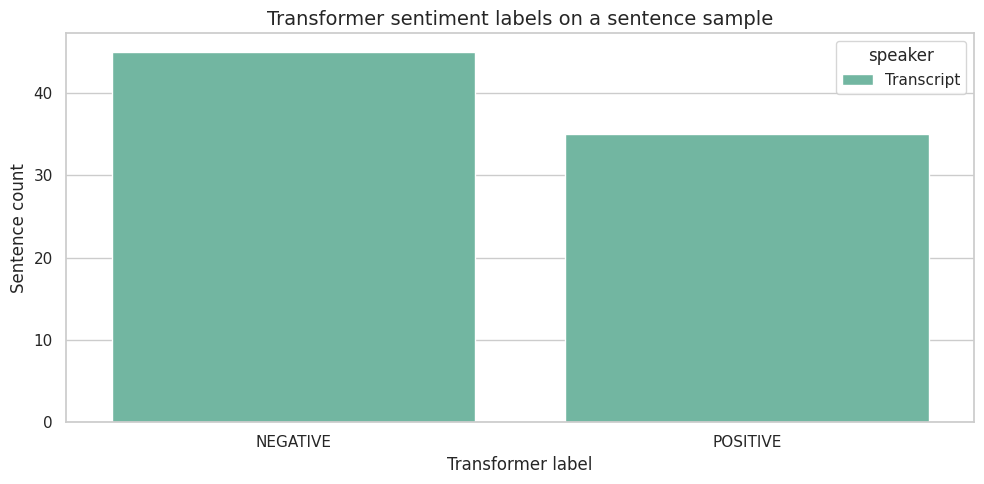

In [90]:

try:
    from transformers import pipeline

    transformer_sentiment = pipeline('sentiment-analysis')
    sample_for_transformer = df.sample(min(80, len(df)), random_state=42).copy()

    transformer_results = transformer_sentiment(
        sample_for_transformer['text'].str.slice(0, 512).tolist(),
        truncation=True
    )
    sample_for_transformer['transformer_label'] = [result['label'] for result in transformer_results]
    sample_for_transformer['transformer_score'] = [result['score'] for result in transformer_results]

    display(sample_for_transformer[['speaker', 'debate', 'sentiment', 'compound', 'transformer_label', 'transformer_score', 'text']].head(20))

    plt.figure(figsize=(10, 5))
    sns.countplot(data=sample_for_transformer, x='transformer_label', hue='speaker')
    plt.title('Transformer sentiment labels on a sentence sample')
    plt.xlabel('Transformer label')
    plt.ylabel('Sentence count')
    plt.tight_layout()
except ImportError:
    print('transformers is not installed. To try this section, run: %pip install transformers torch')
except Exception as exc:
    print('Transformer sentiment could not run:', exc)